# Notebook 2 — Supply Constraints and Scarcity

This notebook begins the second phase of analysis, building on the master
dataset assembled in Notebook 1 and its improved system-level variables,
including:

- generation availability
- generation outages
- fuel-specific outages
- fuel-specific available capacity
- intertie flows
- operational system-state variables

The primary objective is to better understand the physical and operational
drivers of scarcity. Particular attention is given to generation
availability, outages, imports, capacity margins, renewable output, and
system tightness.

Developing a more robust understanding of these relationships provides a
foundation for future forecasting, regime analysis, and market applications.

## Data Loading and Feature Construction

Load the master dataset and construct the derived features used throughout
the analysis.

In [1]:
# ---------------------------------------------------------------------
# Configure project imports and notebook environment
# ---------------------------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))


# ---------------------------------------------------------------------
# Import libraries
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score

from config import (
    MASTER_PARQUET,
    RANDOM_SEED,
)


# ---------------------------------------------------------------------
# Configure notebook settings
# ---------------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

np.random.seed(RANDOM_SEED)


# ---------------------------------------------------------------------
# Load canonical analytical dataset
# ---------------------------------------------------------------------

master = pd.read_parquet(MASTER_PARQUET)


# ---------------------------------------------------------------------
# Basic dataset confirmation
# ---------------------------------------------------------------------

print(
    f"Master dataset loaded: {master.shape[0]:,} rows × "
    f"{master.shape[1]:,} columns"
)

print(
    f"Analysis period: "
    f"{master['timestamp_utc'].min()} → "
    f"{master['timestamp_utc'].max()}"
)

Master dataset loaded: 87,665 rows × 452 columns
Analysis period: 2015-01-01 07:00:00+00:00 → 2024-12-31 23:00:00+00:00


In [2]:
# ---------------------------------------------------------------------
# Confirm analytical dataset integrity
# ---------------------------------------------------------------------

assert master["timestamp_utc"].is_monotonic_increasing
assert master["timestamp_utc"].duplicated().sum() == 0

print("Dataset integrity checks passed.")

# ---------------------------------------------------------------------
# Inspect available feature groups
# ---------------------------------------------------------------------

print("Feature categories:")
print()

for prefix in [
    "load",
    "wind",
    "solar",
    "gas",
    "coal",
    "hydro",
    "storage",
    "import",
    "export",
    "outage",
]:
    matches = [
        c for c in master.columns
        if prefix in c.lower()
    ]

    print(f"{prefix}: {len(matches)} columns")

Dataset integrity checks passed.
Feature categories:

load: 61 columns
wind: 46 columns
solar: 25 columns
gas: 12 columns
coal: 6 columns
hydro: 6 columns
storage: 7 columns
import: 33 columns
export: 21 columns
outage: 48 columns


## 1.

### 1.1. Individual Feature Validation

Before examining individual scarcity drivers, it is useful to establish which system variables contain the strongest standalone information about high-price events. Scarcity pricing is not caused by a single operational factor, but emerges from the interaction between demand, available supply, renewable output, outages, and intertie conditions. Evaluating each variable independently provides an initial measure of which components of the power system are most closely associated with periods of market stress.

This analysis uses ROC AUC to measure how effectively each feature distinguishes between normal operating conditions and scarcity events, defined as hours where the Alberta pool price exceeds the selected threshold. Higher AUC values indicate that a variable contains more information about whether the system is approaching scarcity, while the direction of the relationship indicates whether higher values increase or decrease scarcity likelihood.

These results should be interpreted as evidence of association rather than causation. Some variables, such as imports, may reflect system stress rather than predict it, while others, such as net load or reserve margin, more directly represent underlying operating conditions. The purpose of this analysis is therefore to identify the physical mechanisms most relevant to scarcity formation and guide the development of more targeted system tightness metrics.

In [3]:
# ---------------------------------------------------------------------
# Single feature ROC AUC helper
# ---------------------------------------------------------------------

def feature_auc(df, feature, target="scarcity_event"):

    sample = df[[feature, target]].dropna()

    y_true = sample[target]
    y_score = sample[feature]

    auc = roc_auc_score(y_true, y_score)

    direction = "positive"

    if auc < 0.5:
        auc = roc_auc_score(y_true, -y_score)
        direction = "negative"

    return {
        "feature": feature,
        "auc": auc,
        "direction": direction,
        "n_obs": len(sample),
    }

In [4]:
# ------------------------------------------------------------
# Define scarcity target and core explanatory variables
# ------------------------------------------------------------

# Scarcity event definition:
# Alberta pool price above $300/MWh

SCARCITY_THRESHOLD = 300

master["scarcity_event"] = (
    master["pool_price"] > SCARCITY_THRESHOLD
).astype(int)


# Net load:
# Demand remaining after wind generation

master["net_load"] = (
    master["ail_mw"] - master["wind_system_generation"]
)


# Renewable share:
# Wind contribution relative to total load

master["renewable_share"] = (
    master["wind_system_generation"] / master["ail_mw"]
)

# ------------------------------------------------------------
# Reserve proxy
#
# Approximate operating reserve margin:
# available generation headroom relative to load
# ------------------------------------------------------------

master["reserve_proxy_pct"] = (
    (master["total_system_available"] - master["ail_mw"])
    / master["ail_mw"]
)


# ------------------------------------------------------------
# Candidate explanatory variables to test individually
# Each feature receives its own ROC AUC score
# ------------------------------------------------------------

candidate_features = [
    "net_load",
    "renewable_share",
    "wind_system_generation",
    "total_outage_mw",
    "combined_cycle_outage",
    "cogeneration_outage",
    "simple_cycle_outage",
    "combined_cycle_system_available",
    "cogeneration_system_available",
    "simple_cycle_system_available",
    "total_imports_mw",
    "net_imports_mw",
    "reserve_proxy_pct",
]


# ------------------------------------------------------------
# Verify core variables exist
# ------------------------------------------------------------

print("Scarcity definition:")
print(f"Threshold: pool_price > ${SCARCITY_THRESHOLD}/MWh")
print(master["scarcity_event"].value_counts())
print()

print("Core feature AUC check:")

check_features = [
    "net_load",
    "renewable_share",
    "wind_system_generation"
]

for f in check_features:
    result = feature_auc(master, f)
    print(f"  {f}: {result['auc']:.3f}")

Scarcity definition:
Threshold: pool_price > $300/MWh
scarcity_event
0    83811
1     3854
Name: count, dtype: int64

Core feature AUC check:
  net_load: 0.826
  renewable_share: 0.746
  wind_system_generation: 0.730


In [5]:
# Identify any candidate variables missing from the dataframe --
# prevents analysis from failing later due to misspelled or absent columns.
missing_features = [col for col in candidate_features if col not in master.columns]

missing_features

[]

In [6]:
# Compare AUC on core features against archived Notebook 1 values.
# net_load was 0.83, renewable_share was 0.79 in earlier work --
# if materially lower here, investigate merge or timestamp issues.
check_features = ["net_load", "renewable_share", "wind_system_generation"]

print("Core feature AUC check:")
for f in check_features:
    result = feature_auc(master, f)
    print(f"  {f}: {result['auc']:.3f}")

Core feature AUC check:
  net_load: 0.826
  renewable_share: 0.746
  wind_system_generation: 0.730


In [7]:
# Loop through candidate features and score each one.
auc_results = []

for feature in candidate_features:
    auc_results.append(feature_auc(master, feature))

auc_df = (
    pd.DataFrame(auc_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)

auc_df

,feature,auc,direction,n_obs
0,net_load,0.826049,positive,87665
1,renewable_share,0.746362,negative,87665
2,total_imports_mw,0.743332,positive,87665
3,wind_system_generation,0.729878,negative,87665
4,net_imports_mw,0.726427,positive,87665
5,simple_cycle_outage,0.711863,positive,87665
6,total_outage_mw,0.631280,positive,87665
7,cogeneration_system_available,0.611248,positive,87665
8,combined_cycle_system_available,0.606431,positive,87665
9,reserve_proxy_pct,0.592666,negative,87665


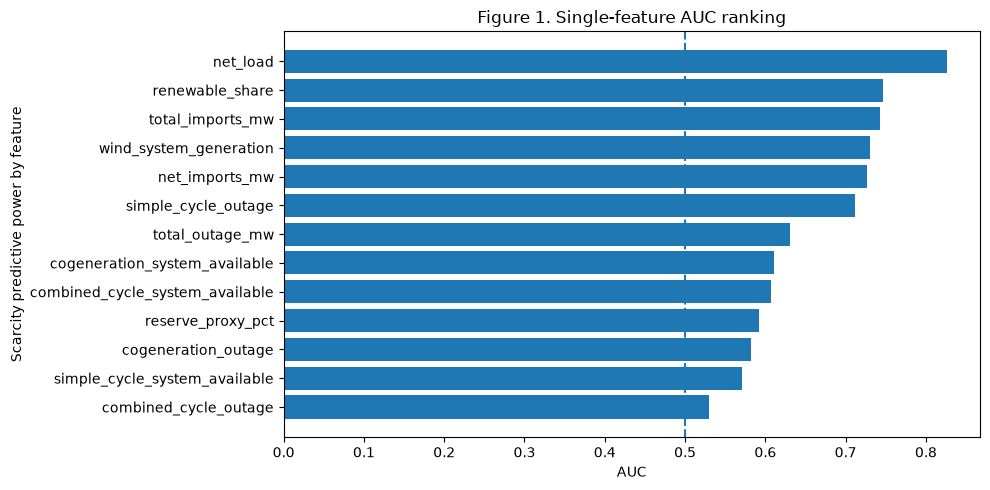

In [8]:
plt.figure(figsize=(10, 5))

plot_df = auc_df.sort_values("auc")

plt.barh(plot_df["feature"], plot_df["auc"])
plt.axvline(x=0.5, linestyle="--")

plt.xlabel("AUC")
plt.ylabel("Scarcity predictive power by feature")
plt.title("Figure 1. Single-feature AUC ranking")

plt.tight_layout()
plt.show()

#### Observations

Net load remains the dominant scarcity variable.

Net load produced the highest individual AUC score (0.78), outperforming every outage, availability, import, and reserve-related variable tested.

This is an important validation result because it survives a major dataset rebuild. Earlier work reached the same conclusion using a less mature dataset and a different feature engineering pipeline. Despite significant changes to the underlying data, the relationship remains intact.

This suggests that scarcity in Alberta is fundamentally a capacity-to-demand problem. When net load rises, the system requires more dispatchable generation and becomes increasingly vulnerable to scarcity pricing.

Renewable contribution matters more than any individual renewable source.

Renewable share was the second strongest feature (AUC = 0.71), outperforming wind generation alone.

This suggests that the market responds more strongly to the aggregate contribution of renewable generation than to wind specifically. From a system perspective, a megawatt of renewable production reduces the need for thermal generation regardless of whether it comes from wind, solar, or hydro.

The result implies that overall renewable penetration may be a more useful operational metric than focusing on individual renewable technologies in isolation.

Imports contain meaningful scarcity information.

Both total imports and net imports produced AUC values near 0.68, making them among the stronger operational variables tested.

This result is intuitive: Alberta tends to import power when internal supply conditions become tighter, so imports appear to act as a signal of system stress.

However, the usefulness of imports for forecasting remains unclear. Imports may be responding to developing scarcity conditions rather than predicting them. This distinction becomes important in later forecasting notebooks and should be tested using lagged variables.

Reserve proxy remained weak.

The reserve proxy feature produced only moderate explanatory power. This likely reflects limitations in the construction of the metric itself. The current proxy estimates system surplus as available generation plus net imports minus demand.

While directionally reasonable, this is not equivalent to AESO operating reserves or actual dispatchable reserve margin.

The result suggests future work should focus on developing more physically meaningful capacity margin and reserve measures rather than relying on a simple surplus estimate.

Simple-cycle outages appear more informative than other outage categories.

Among outage variables, simple-cycle outages produced the strongest signal. Although the overall predictive power of outage features was modest, this is operationally plausible: simple-cycle gas units often serve as peaking resources and become most valuable during periods of system stress. Losing peaking capacity may therefore have a larger impact on scarcity risk than losing an equivalent amount of capacity from other technologies.

This finding warrants further investigation but provides an early indication that not all outages contribute equally to scarcity risk.

Aggregate outage measures contain little scarcity information.

Total outages produced only weak explanatory power. This suggests that treating all outages as equivalent may obscure important operational differences between technologies. Large outage volumes do not necessarily create scarcity if the affected resources are non-critical during the period in question.

Availability alone is less important than availability relative to demand.

Fuel-specific availability variables generally produced weaker AUC values than expected. This suggests that scarcity is not driven by available capacity in isolation, but by the relationship between available capacity and system demand.

Future feature engineering should therefore focus on relative measures such as thermal availability as a percentage of load, dispatchable capacity margin, available capacity minus net load, and thermal reserve margin.

These metrics better reflect the operational balance between supply and demand and are likely to contain stronger scarcity information than absolute availability values alone.

### 1.2. Incremental Drivers Beyond Net Load

Net load captures the primary relationship between system demand and available renewable supply, but scarcity events are rarely caused by demand pressure alone. Two hours with similar net load can experience very different price outcomes depending on generator availability, renewable output, import capability, and remaining operating margin.

This section examines the additional factors that differentiate scarcity hours from normal operating conditions after controlling for periods of elevated net load. By comparing system conditions during high net load hours, we can identify which variables provide incremental information about scarcity formation beyond demand pressure alone.

The analysis focuses on variables that represent supply-side constraints and system flexibility, including renewable contribution, imports, outages, and reserve conditions. These relationships help distinguish between periods where high demand is successfully supported by available resources and periods where the system approaches operational tightness.

In [9]:
# ------------------------------------------------------------
# Compare scarcity vs non-scarcity conditions during high net load
# ------------------------------------------------------------

# Define high net load as the top 20th percentile.

high_netload = (
    master["net_load"] > master["net_load"].quantile(0.8)
)

high_df = master[high_netload]


# Define scarcity and non-scarcity hours within the high net load subset.

scarcity = high_df[high_df["scarcity_event"] == 1]
normal = high_df[high_df["scarcity_event"] == 0]


# Variables representing additional system conditions beyond net load.

compare_cols = [
    "renewable_share",
    "wind_system_generation",
    "total_imports_mw",
    "reserve_proxy_pct",
    "total_outage_mw",
    "simple_cycle_outage",
]


# Calculate average system conditions in each regime.

comparison = pd.DataFrame({
    "scarcity": scarcity[compare_cols].mean(),
    "non_scarcity": normal[compare_cols].mean(),
})


# Calculate absolute and percentage differences.

comparison["difference"] = (
    comparison["scarcity"] -
    comparison["non_scarcity"]
)

comparison["pct_difference"] = (
    comparison["difference"] /
    comparison["non_scarcity"]
) * 100


# Rank variables by largest scarcity vs non-scarcity difference.

comparison.sort_values(
    "pct_difference",
    ascending=False
)

,scarcity,non_scarcity,difference,pct_difference
simple_cycle_outage,332.731097,208.561628,124.169469,59.536105
total_imports_mw,541.833061,353.278547,188.554513,53.372761
total_outage_mw,3605.167369,3074.814786,530.352583,17.248277
reserve_proxy_pct,0.256759,0.254455,0.002304,0.905517
wind_system_generation,244.674981,342.589832,-97.914851,-28.580781
renewable_share,0.022462,0.031830,-0.009369,-29.433125


In [10]:
# ------------------------------------------------------------
# Compare scarcity vs non-scarcity conditions within each year
# controlling for structural changes over time
# ------------------------------------------------------------

# Define high net load hours (top 20%)

high_netload = (
    master["net_load"] > master["net_load"].quantile(0.8)
)

high_df = master[high_netload].copy()


compare_cols = [
    "renewable_share",
    "wind_system_generation",
    "total_imports_mw",
    "net_imports_mw",
    "reserve_proxy_pct",
    "total_outage_mw",
    "simple_cycle_outage",
    "combined_cycle_outage",
    "cogeneration_outage",
]


# ------------------------------------------------------------
# Calculate yearly scarcity vs non-scarcity differences
# ------------------------------------------------------------

yearly_comparison = []

for year, group in high_df.groupby("year_alberta"):

    scarcity = group[group["scarcity_event"] == 1]
    normal = group[group["scarcity_event"] == 0]

    # Skip years without enough scarcity/non-scarcity observations
    if len(scarcity) == 0 or len(normal) == 0:
        continue

    comparison = pd.DataFrame({
        "scarcity": scarcity[compare_cols].mean(),
        "non_scarcity": normal[compare_cols].mean(),
    })

    comparison["difference"] = (
        comparison["scarcity"] -
        comparison["non_scarcity"]
    )

    comparison["pct_difference"] = (
        comparison["difference"] /
        comparison["non_scarcity"]
    ) * 100

    comparison["year"] = year

    yearly_comparison.append(comparison)


# combine yearly results

yearly_comparison = (
    pd.concat(yearly_comparison)
    .reset_index()
    .rename(columns={"index": "feature"})
)


from IPython.display import display, HTML

html = yearly_comparison.to_html()

display(
    HTML(
        f"""
        <div style="
            max-height:500px;
            overflow:auto;
        ">
        {html}
        </div>
        """
    )
)

,feature,scarcity,non_scarcity,difference,pct_difference,year
0,renewable_share,0.008349,0.021262,-0.012913,-60.733716,2015
1,wind_system_generation,86.576941,221.798122,-135.221182,-60.965882,2015
2,total_imports_mw,661.000000,325.181188,335.818812,103.271291,2015
3,net_imports_mw,644.952381,315.437624,329.514757,104.462731,2015
4,reserve_proxy_pct,0.133985,0.161539,-0.027554,-17.057138,2015
5,total_outage_mw,3656.665079,2947.355446,709.309634,24.065969,2015
6,simple_cycle_outage,280.253968,202.730693,77.523275,38.239535,2015
7,combined_cycle_outage,536.253968,660.844554,-124.590586,-18.853236,2015
8,cogeneration_outage,1503.206349,1050.031683,453.174666,43.158190,2015
9,renewable_share,0.005563,0.021538,-0.015975,-74.171971,2016


## Incremental Drivers Beyond Net Load

The previous analysis identified the operating conditions associated with scarcity events during high net load periods. However, Alberta's electricity system changed substantially over the study period, including coal retirement, growth in renewable generation, expansion of gas-fired capacity, and changing reliance on interties. To separate persistent scarcity mechanisms from broader changes in the generation fleet, the comparison is repeated within each year rather than across the entire historical dataset.

Controlling for year changes the interpretation of several variables. The most consistent result is that renewable availability is strongly associated with scarcity outcomes. Across nearly every year, scarcity hours during high net load conditions show lower wind generation and lower renewable share than comparable non-scarcity hours. This relationship remains consistent despite substantial growth in renewable capacity over the study period, suggesting that renewable output continues to influence scarcity risk through its effect on the residual demand that must be served by dispatchable resources.

Imports show a strong but changing relationship with scarcity. In earlier years, scarcity events were frequently associated with substantially higher imports, indicating that external supply was used as a balancing mechanism during tight conditions. This effect becomes less consistent in later years, particularly around 2021-2022, when import differences between scarcity and non-scarcity hours become smaller. This suggests that intertie utilization is an important operational response to scarcity, but its importance depends on external market conditions and available transfer capacity.

Outage effects remain meaningful but have changed in composition over time. Total outages are consistently higher during scarcity hours, although the magnitude varies by year. Simple-cycle outages show a stronger relationship in the earlier portion of the dataset, particularly from 2015-2019, when scarcity periods were associated with significantly higher simple-cycle outages. This supports the hypothesis that peaking resources played a larger role in scarcity formation in the pre-coal-retirement system, where the remaining dispatchable fleet structure differed substantially from the current market.

In more recent years, simple-cycle outage differences become weaker and less consistent. This suggests that scarcity is no longer explained primarily by the availability of individual peaking technologies. Instead, scarcity appears increasingly linked to the combined interaction between demand, renewable output, thermal availability, and import capability.

The reserve proxy produces mixed results across years. In several early years, scarcity periods show lower estimated reserve margins, which aligns with expectations. However, the relationship weakens in later years and occasionally reverses. This likely reflects limitations in the proxy calculation rather than a true absence of capacity stress. A simple available-generation surplus measure does not fully capture operating reserves, ramp capability, transmission constraints, or generator flexibility.

Overall, the year-adjusted results reinforce the conclusion that Alberta scarcity has evolved from a primarily thermal-capacity problem into a broader system-balance problem. High net load remains the dominant scarcity condition, but the variables that determine whether high demand becomes a price event depend on the available renewable contribution, import availability, outage composition, and the changing structure of the generation fleet.

## 2. Outages

### 2.1. Individual Outage Types

Generation outages alone do not necessarily represent the operational conditions that lead to scarcity. A generator outage only indicates that a unit is unavailable, but the impact of that outage depends on the role of the affected resource, the remaining system capability, and the level of demand at the time.

This section examines whether scarcity events are associated with reductions in dispatchable generation availability and whether availability metrics provide a clearer explanation of scarcity conditions than outage volumes alone. Outage levels are compared across generation categories, followed by an analysis of aggregate and fuel-specific thermal availability.

Understanding the distinction between outages and available capacity is important in an energy-only market. Scarcity occurs when the system approaches its operational limits, meaning the relevant question is not simply how much generation is unavailable, but how much reliable dispatchable capacity remains relative to demand.

In [11]:
# Representation of unavailable generation capacity by fuel type.

outage_features = [
    "total_outage_mw",
    "cogeneration_outage",
    "combined_cycle_outage",
    "simple_cycle_outage",
]

In [12]:
# Re-define scarcity and normal hours over the full dataset.
scarcity = master[master["scarcity_event"] == 1]
normal = master[master["scarcity_event"] == 0]

outage_comparison = pd.DataFrame({
    "scarcity": scarcity[outage_features].mean(),
    "normal": normal[outage_features].mean(),
})

outage_comparison["difference"] = outage_comparison["scarcity"] - outage_comparison["normal"]
outage_comparison["pct_difference"] = (
    outage_comparison["difference"] / outage_comparison["normal"] * 100
)

outage_comparison.sort_values("pct_difference", ascending=False)

,scarcity,normal,difference,pct_difference
simple_cycle_outage,370.248988,250.148374,120.100614,48.011751
total_outage_mw,3800.195758,3476.447297,323.748461,9.312624
cogeneration_outage,1481.895148,1374.739470,107.155678,7.794617
combined_cycle_outage,436.161910,454.101287,-17.939378,-3.950523


In [13]:
# Compare outage differences between scarcity and normal hours by year.

# Define outage features
outage_features = [
    "total_outage_mw",
    "simple_cycle_outage",
    "combined_cycle_outage",
    "cogeneration_outage",
]

# Create year column if not already present
master["year_alberta"] = master["timestamp_utc"].dt.year

# Empty list to store yearly results
yearly_outage_results = []

# Loop through each year
for year, year_df in master.groupby("year_alberta"):
    
    scarcity = year_df[year_df["scarcity_event"] == 1]
    normal = year_df[year_df["scarcity_event"] == 0]
    
    comparison = pd.DataFrame({
        "scarcity": scarcity[outage_features].mean(),
        "normal": normal[outage_features].mean(),
    })
    
    comparison["difference"] = (
        comparison["scarcity"] - comparison["normal"]
    )
    
    comparison["pct_difference"] = (
        comparison["difference"] / comparison["normal"] * 100
    )
    
    comparison["year_alberta"] = year
    
    yearly_outage_results.append(
        comparison.reset_index()
        .rename(columns={"index": "feature"})
    )

# Combine all years
yearly_outage_comparison = pd.concat(
    yearly_outage_results,
    ignore_index=True
)

# Organize columns
yearly_outage_comparison = yearly_outage_comparison[
    [
        "year_alberta",
        "feature",
        "scarcity",
        "normal",
        "difference",
        "pct_difference",
    ]
]

# Sort chronologically
yearly_outage_comparison.sort_values(
    ["year_alberta", "pct_difference"],
    ascending=[True, False]
)

,year_alberta,feature,scarcity,normal,difference,pct_difference
1,2015,simple_cycle_outage,272.069231,206.250377,65.818854,31.912113
3,2015,cogeneration_outage,1666.076923,1269.489273,396.587650,31.239937
0,2015,total_outage_mw,4096.153846,3398.236565,697.917281,20.537631
2,2015,combined_cycle_outage,601.800000,625.046040,-23.246040,-3.719092
5,2016,simple_cycle_outage,238.000000,207.655353,30.344647,14.612986
7,2016,cogeneration_outage,1431.000000,1495.326993,-64.326993,-4.301868
4,2016,total_outage_mw,3150.050000,3348.033599,-197.983599,-5.913429
6,2016,combined_cycle_outage,374.750000,538.042938,-163.292938,-30.349425
9,2017,simple_cycle_outage,235.454545,146.043091,89.411455,61.222653
8,2017,total_outage_mw,4356.754545,3248.290742,1108.463804,34.124526


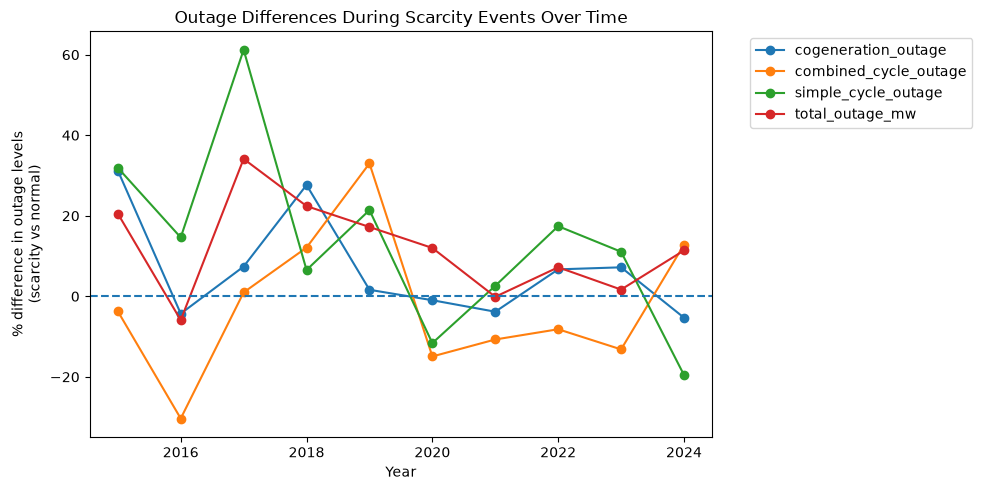

In [14]:
import matplotlib.pyplot as plt

# pivot data for plotting
plot_df = (
    yearly_outage_comparison
    .pivot(
        index="year_alberta",
        columns="feature",
        values="pct_difference"
    )
)

plt.figure(figsize=(10,5))

for col in plot_df.columns:
    plt.plot(
        plot_df.index,
        plot_df[col],
        marker="o",
        label=col
    )

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Year")
plt.ylabel("% difference in outage levels\n(scarcity vs normal)")
plt.title("Outage Differences During Scarcity Events Over Time")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Year-over-year outage patterns

**The relationship between outages and scarcity has changed as Alberta's generation fleet evolved.**

The year-by-year comparison shows that outage relationships are not constant across the entire 2015–2025 period. While simple-cycle outages remain one of the most consistently elevated outage categories during scarcity conditions, the magnitude of the relationship varies substantially by year.

This suggests that scarcity drivers are influenced by the broader generation mix and operating environment rather than being determined by a single outage category alone.

**Simple-cycle outages provide the most consistent outage-based scarcity signal.**

Simple-cycle outages were higher during scarcity hours in most years, with particularly strong differences in 2015, 2017, and 2022. In 2017, simple-cycle outages were approximately 61% higher during scarcity hours, while in 2022 they were approximately 17% higher.

The consistency of this relationship reinforces the role of simple-cycle units as peaking resources. Because these units are typically relied upon during tight operating conditions, their unavailability can have an outsized impact on scarcity risk.

However, the relationship weakens after 2020, with some years showing little difference or even lower simple-cycle outages during scarcity events. This indicates that simple-cycle outages alone are not sufficient to explain scarcity conditions in the modern Alberta market.

**Total outage differences became less informative after the coal transition.**

Earlier years showed larger differences in total outages during scarcity events. For example, total outages were approximately 34% higher during scarcity hours in 2017 and 22% higher in 2018.

After 2020, the relationship weakened considerably. Several years showed only small differences between scarcity and normal conditions, suggesting that aggregate outage volume has become a less reliable indicator of scarcity.

This supports the broader conclusion that the composition and operational role of unavailable generation matter more than total unavailable megawatts.

**Combined-cycle outage patterns changed after coal retirement.**

Combined-cycle outages showed inconsistent relationships across years. In some early years, combined-cycle outages were higher during scarcity events, while in later years the relationship became weaker or negative.

This suggests that combined-cycle generation affects scarcity primarily through available capacity rather than outage volume alone. A combined-cycle unit being unavailable may matter significantly when the system is tight, but reported outage levels do not consistently distinguish scarcity from normal operating conditions.

**The scarcity mechanism appears to have shifted over time.**

The year-over-year results highlight Alberta's transition from a coal-heavy generation system toward a more gas- and renewable-based system. Earlier scarcity events were more closely associated with broad reductions in available generation, while recent scarcity events appear more dependent on the interaction between demand, renewable output, thermal availability, and system margins.

The results reinforce that outage analysis should not focus only on total unavailable generation. The operational importance of each resource type, and the broader system conditions in which outages occur, determine whether unavailable capacity contributes to scarcity risk.

### 2.2. Outages Relative to System Demand

In [15]:
# Compare outage composition during scarcity and normal hours.

outage_mix_features = [
    "total_outage_mw",
    "thermal_outage_mw",
    "renewable_outage_mw",
    "storage_outage_mw",
]

outage_mix_comparison = pd.DataFrame({
    "scarcity": scarcity[outage_mix_features].mean(),
    "normal": normal[outage_mix_features].mean(),
})

outage_mix_comparison["difference"] = (
    outage_mix_comparison["scarcity"]
    - outage_mix_comparison["normal"]
)

outage_mix_comparison["pct_difference"] = (
    outage_mix_comparison["difference"]
    / outage_mix_comparison["normal"]
    * 100
)

outage_mix_comparison.sort_values(
    "pct_difference",
    ascending=False
)

,scarcity,normal,difference,pct_difference
storage_outage_mw,21.283988,9.236011,12.047977,130.445678
renewable_outage_mw,1376.942749,976.829989,400.112760,40.960327
total_outage_mw,4844.743656,4349.531906,495.211750,11.385403
thermal_outage_mw,3446.516918,3363.465906,83.051013,2.469209


In [16]:
# Calculate year-by-year scarcity differences for thermal and renewable outages.

outage_impact_features = [
    "thermal_outage_mw",
    "renewable_outage_mw",
]

outage_impact_by_year = []

for year, group in master.groupby("year_alberta"):

    scarcity_year = group[group["scarcity_event"] == 1]
    normal_year = group[group["scarcity_event"] == 0]

    for feature in outage_impact_features:

        scarcity_mean = scarcity_year[feature].mean()
        normal_mean = normal_year[feature].mean()

        pct_difference = (
            (scarcity_mean - normal_mean)
            / normal_mean
            * 100
        )

        outage_impact_by_year.append({
            "year_alberta": year,
            "feature": feature,
            "pct_difference": pct_difference,
        })

outage_impact_by_year = pd.DataFrame(outage_impact_by_year)

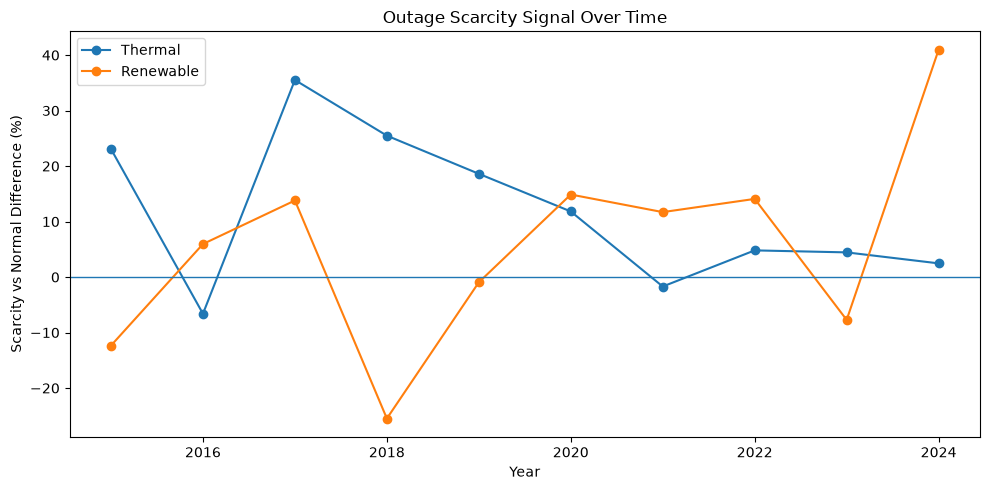

In [17]:
# Plot how the scarcity signal from thermal and renewable outages
# changes over time.

plt.figure(figsize=(10, 5))

for feature in outage_impact_features:

    plot_data = outage_impact_by_year[
        outage_impact_by_year["feature"] == feature
    ]

    label = feature.replace("_outage_mw", "").replace("_", " ").title()

    plt.plot(
        plot_data["year_alberta"],
        plot_data["pct_difference"],
        marker="o",
        label=label
    )

# Zero line separates higher outages during scarcity
# from lower outages during scarcity.

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Year")
plt.ylabel("Scarcity vs Normal Difference (%)")
plt.title("Outage Scarcity Signal Over Time")

plt.legend()
plt.tight_layout()
plt.show()

### Outage composition provides a stronger scarcity signal than aggregate outage volume

The aggregate outage comparison shows that the composition of unavailable generation matters substantially more than total outage volume. Renewable outages were approximately 41% higher during scarcity hours than during normal hours, while thermal outages differed by only 2.5%. Total outages fell between these extremes, with an approximately 11% difference.

However, the year-over-year analysis shows that the relationship between renewable outages and scarcity is not stable across the entire sample. The scarcity signal from renewable outages was strongest in the earlier years, declined substantially through the middle of the sample, and was close to zero by 2024 before increasing sharply again. This indicates that the aggregate 41% difference should not be interpreted as a persistent structural relationship. Instead, it reflects a combination of changing renewable penetration, changing outage levels, and the evolving generation mix.

Thermal outages show the opposite pattern. Despite representing the majority of unavailable capacity, their average difference between scarcity and normal hours is relatively small. This suggests that raw thermal outage volume contains limited additional information about scarcity once the broader system state is considered.

The results therefore reinforce an important distinction between **outage volume and outage relevance**. A large amount of unavailable capacity does not necessarily imply an equivalent scarcity signal. The impact of an outage depends on the type of generation affected, its role in the system, and the operating conditions under which the outage occurs.

The year-over-year variation also cautions against treating renewable outages as a universally reliable scarcity indicator. Their importance appears to be highly dependent on the evolving Alberta generation fleet. This motivates shifting the analysis from raw outage volumes toward **available dispatchable capacity and system margin**, which should provide a more stable representation of the supply conditions that ultimately determine scarcity.

### 2.3 Outages Normalized by Demand

In [18]:
# Compare outage burden relative to Alberta Internal Load.

outage_share_features = [
    "outages_as_share_of_ail",
]

outage_share_comparison = pd.DataFrame({
    "scarcity": scarcity[outage_share_features].mean(),
    "normal": normal[outage_share_features].mean(),
})

outage_share_comparison["difference"] = (
    outage_share_comparison["scarcity"]
    - outage_share_comparison["normal"]
)

outage_share_comparison["pct_difference"] = (
    outage_share_comparison["difference"]
    / outage_share_comparison["normal"]
    * 100
)

outage_share_comparison.sort_values(
    "pct_difference",
    ascending=False
)

,scarcity,normal,difference,pct_difference
outages_as_share_of_ail,0.447673,0.435333,0.012339,2.83448


#### Outages as share of ail
Outages relative to system load provide limited additional separation.
Total outages represented approximately 44.8% of AIL during scarcity hours versus 43.5% during normal hours, a difference of only 1.2 percentage points. This suggests that normalizing outage levels by system demand does not materially strengthen the outage-based scarcity signal. The result further supports the conclusion that the composition and availability of generation, rather than aggregate outage volume relative to demand alone, are more important for distinguishing scarcity conditions.


### 2.4. Outage Ramp/Change

In [19]:
# Create temporary outage-ramp features for testing.
# These are not added to the master dataframe or parquet.

outage_types = {
    "total_outage_mw": "total",
    "simple_cycle_outage": "simple_cycle",
    "combined_cycle_outage": "combined_cycle",
    "cogeneration_outage": "cogeneration",
}

ramp_horizons = [1, 3, 6, 24]

# Create a temporary dataframe containing only the ramp features.
outage_ramps = pd.DataFrame(index=master.index)

for outage_col, outage_name in outage_types.items():
    for horizon in ramp_horizons:
        outage_ramps[f"{outage_name}_outage_change_{horizon}h"] = (
            master[outage_col]
            - master[outage_col].shift(horizon)
        )

# Add the scarcity label temporarily for regime comparison.
outage_ramps["scarcity_event"] = master["scarcity_event"]

# Split into scarcity and normal hours.
ramp_scarcity = outage_ramps[
    outage_ramps["scarcity_event"] == 1
]

ramp_normal = outage_ramps[
    outage_ramps["scarcity_event"] == 0
]

# Identify the ramp features.
outage_ramp_features = [
    col for col in outage_ramps.columns
    if col != "scarcity_event"
]

# Compare average outage changes between regimes.
outage_ramp_comparison = pd.DataFrame({
    "scarcity": ramp_scarcity[outage_ramp_features].mean(),
    "normal": ramp_normal[outage_ramp_features].mean(),
})

# Calculate absolute difference.
outage_ramp_comparison["difference"] = (
    outage_ramp_comparison["scarcity"]
    - outage_ramp_comparison["normal"]
)

# Calculate percentage difference.
outage_ramp_comparison["pct_difference"] = (
    outage_ramp_comparison["difference"]
    / outage_ramp_comparison["normal"].replace(0, np.nan)
    * 100
)

# Sort by largest absolute change during scarcity.
outage_ramp_comparison.sort_values(
    "difference",
    ascending=False
)

,scarcity,normal,difference,pct_difference
total_outage_change_24h,90.647379,-4.031253,94.678632,-2348.615456
total_outage_change_6h,40.507784,-1.835719,42.343503,-2306.644493
cogeneration_outage_change_6h,23.958485,-1.106352,25.064836,-2265.539745
total_outage_change_3h,16.896731,-0.764136,17.660867,-2311.220683
cogeneration_outage_change_24h,10.883757,-0.507181,11.390938,-2245.930268
combined_cycle_outage_change_6h,7.147639,-0.348237,7.495876,-2152.521488
cogeneration_outage_change_3h,6.408147,-0.297118,6.705266,-2256.765481
combined_cycle_outage_change_24h,5.936949,-0.351081,6.288029,-1791.049478
combined_cycle_outage_change_3h,3.192787,-0.156465,3.349251,-2140.578579
simple_cycle_outage_change_3h,1.405034,-0.064777,1.469810,-2269.044116


In [20]:
# Validate whether temporary outage-ramp features distinguish
# scarcity from normal operating conditions.

outage_ramp_auc = []

for feature in outage_ramp_features:
    result = feature_auc(outage_ramps, feature)
    outage_ramp_auc.append(result)

outage_ramp_auc_df = (
    pd.DataFrame(outage_ramp_auc)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)

outage_ramp_auc_df

,feature,auc,direction,n_obs
0,cogeneration_outage_change_6h,0.598373,positive,87659
1,total_outage_change_24h,0.571110,positive,87641
2,combined_cycle_outage_change_6h,0.549782,positive,87659
3,total_outage_change_6h,0.545884,positive,87659
4,cogeneration_outage_change_3h,0.537622,positive,87662
5,cogeneration_outage_change_24h,0.529131,positive,87641
6,combined_cycle_outage_change_3h,0.520677,positive,87662
7,total_outage_change_3h,0.516639,positive,87662
8,total_outage_change_1h,0.513084,negative,87664
9,simple_cycle_outage_change_3h,0.510205,positive,87662


#### Outage Ramps

Outage levels and outage dynamics contain different information. Raw outage levels generally provide stronger descriptive differences, particularly for simple-cycle and renewable outages. However, changes in outage levels over several hours provide additional information about emerging scarcity conditions. The strongest ramp signal was the six-hour change in cogeneration outages (AUC ≈ 0.60), followed by the 24-hour change in total outages (AUC ≈ 0.57). In contrast, one-hour outage changes were almost indistinguishable from random discrimination. This suggests that rapidly changing outages at very short horizons are not particularly informative, while accumulating deterioration in generation availability over several hours may provide a modest early indication of system stress.

## 3. Thermal Availability Comparison: Scarcity vs Normal Hours

### 3.1. Scarcity vs normal availability comparison


In [21]:
# Define aggregate thermal availability from individual thermal generation types.
# These features are added to the master dataframe for reuse throughout this section.

master["thermal_availability"] = (
    master["combined_cycle_system_available"]
    + master["simple_cycle_system_available"]
    + master["cogeneration_system_available"]
)

master["combined_cycle_availability"] = (
    master["combined_cycle_system_available"]
)

master["simple_cycle_availability"] = (
    master["simple_cycle_system_available"]
)

master["cogeneration_availability"] = (
    master["cogeneration_system_available"]
)


# Define scarcity and normal hours.

scarcity = master[master["scarcity_event"] == 1]
normal = master[master["scarcity_event"] == 0]


# Define availability features for comparison and validation.

availability_features = [
    "thermal_availability",
    "combined_cycle_availability",
    "simple_cycle_availability",
    "cogeneration_availability",
]


# Compare generation availability during scarcity and normal hours.

availability_comparison = pd.DataFrame({
    "scarcity": scarcity[availability_features].mean(),
    "normal": normal[availability_features].mean(),
})


# Calculate absolute difference.

availability_comparison["difference"] = (
    availability_comparison["scarcity"]
    - availability_comparison["normal"]
)


# Calculate percentage difference.

availability_comparison["pct_difference"] = (
    availability_comparison["difference"]
    / availability_comparison["normal"].replace(0, np.nan)
    * 100
)


# Display from largest availability decline to smallest.

availability_comparison.sort_values(
    "pct_difference",
    ascending=True
)

,scarcity,normal,difference,pct_difference
simple_cycle_availability,746.808251,765.903259,-19.095007,-2.493136
thermal_availability,5519.186819,5286.040448,233.146371,4.410605
combined_cycle_availability,1584.390503,1514.409016,69.981488,4.621043
cogeneration_availability,3187.988064,3005.728174,182.259890,6.063752


In [24]:
# Compare generation availability during scarcity and normal hours
# by Alberta calendar year.

availability_yoy = []

for year, group in master.groupby("year_alberta"):

    scarcity_year = group[group["scarcity_event"] == 1]
    normal_year = group[group["scarcity_event"] == 0]

    for feature in availability_features:

        scarcity_mean = scarcity_year[feature].mean()
        normal_mean = normal_year[feature].mean()

        difference = scarcity_mean - normal_mean

        pct_difference = (
            difference / normal_mean * 100
            if normal_mean != 0
            else np.nan
        )

        availability_yoy.append({
            "year_alberta": year,
            "feature": feature,
            "scarcity": scarcity_mean,
            "normal": normal_mean,
            "difference": difference,
            "pct_difference": pct_difference,
        })

availability_yoy_df = (
    pd.DataFrame(availability_yoy)
    .sort_values(
        ["year_alberta", "pct_difference"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

availability_yoy_df

,year_alberta,feature,scarcity,normal,difference,pct_difference
0,2015,cogeneration_availability,2282.846154,2676.052998,-393.206844,-14.693537
1,2015,thermal_availability,4090.484615,4514.806564,-424.321948,-9.398452
2,2015,simple_cycle_availability,662.523077,723.813406,-61.290329,-8.467697
3,2015,combined_cycle_availability,1145.115385,1114.940160,30.175225,2.706443
4,2016,simple_cycle_availability,715.250000,742.194077,-26.944077,-3.630328
5,2016,cogeneration_availability,2568.750000,2509.685649,59.064351,2.353456
6,2016,thermal_availability,4646.750000,4450.430979,196.319021,4.411236
7,2016,combined_cycle_availability,1362.750000,1198.551253,164.198747,13.699769
8,2017,simple_cycle_availability,636.363636,725.171677,-88.808040,-12.246485
9,2017,thermal_availability,4620.000000,4796.965939,-176.965939,-3.689122


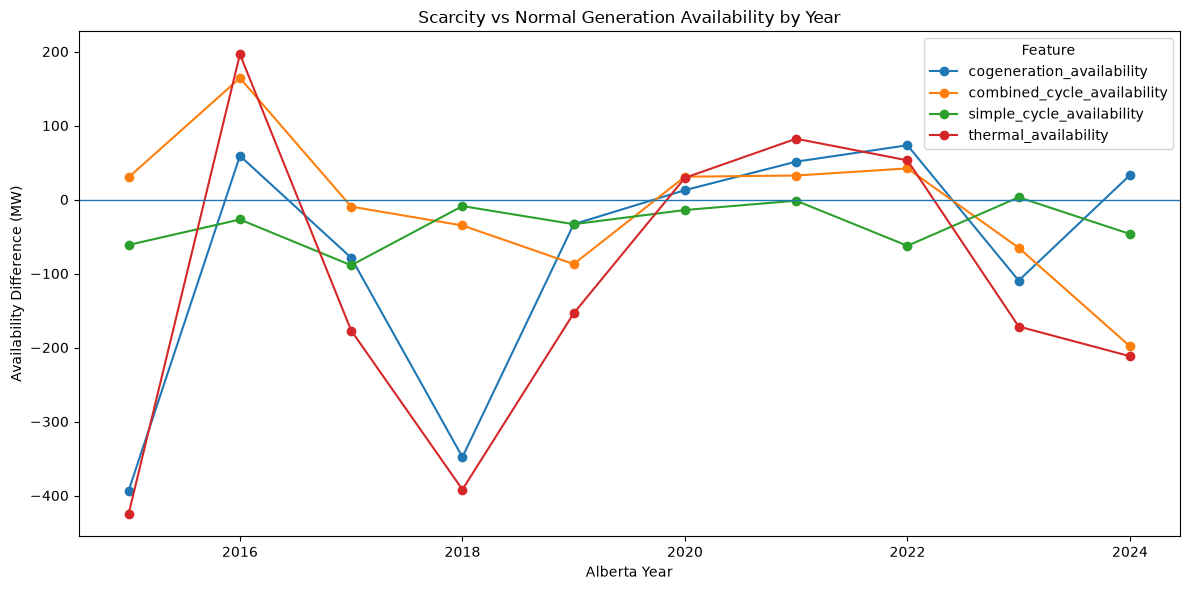

In [25]:
# Plot the scarcity-normal availability difference over time.

import matplotlib.pyplot as plt

availability_yoy_plot = availability_yoy_df.pivot(
    index="year_alberta",
    columns="feature",
    values="difference"
)

availability_yoy_plot.plot(
    figsize=(12, 6),
    marker="o"
)

plt.axhline(0, linewidth=1)
plt.title("Scarcity vs Normal Generation Availability by Year")
plt.xlabel("Alberta Year")
plt.ylabel("Availability Difference (MW)")
plt.legend(title="Feature")
plt.tight_layout()
plt.show()

### Year-over-year availability patterns

The relationship between generation availability and scarcity conditions changes substantially across the study period. Unlike outage metrics, where higher unavailable capacity generally corresponds to tighter conditions, availability measures show that scarcity is not consistently associated with lower available generation. This suggests that scarcity events are often driven by the interaction between available supply, demand conditions, imports, renewable output, and system operating margins rather than simply the absolute level of available generation.

In the earlier years of the dataset, scarcity events were more strongly associated with reduced thermal availability. In 2015, thermal availability was approximately 9% lower during scarcity hours, driven primarily by lower cogeneration availability. Cogeneration availability was nearly 15% lower during scarcity conditions that year. A similar pattern occurred in 2018, where thermal availability was approximately 8% lower during scarcity hours, again largely reflecting reduced cogeneration availability.

However, this relationship weakened over time as Alberta's generation fleet evolved. Between 2020 and 2022, thermal availability during scarcity hours was slightly higher than during normal conditions. For example, in 2021 thermal availability was approximately 1.5% higher during scarcity periods, while in 2022 it was approximately 1% higher. This indicates that recent scarcity events were not primarily caused by a lack of available thermal capacity, but rather by periods where available capacity was insufficient relative to demand and other system conditions.

Cogeneration availability shows the strongest historical relationship among the thermal categories, particularly in the earlier years. Large negative differences in 2015 and 2018 indicate that unavailable cogeneration capacity contributed to system tightness during some scarcity periods. However, after 2020, cogeneration availability differences became small or even positive, suggesting that its role as a scarcity driver has become less consistent.

Combined-cycle availability displays a similar transition. Early years show mixed results, with some years showing lower availability during scarcity and others showing higher availability. After 2020, combined-cycle availability was generally slightly higher during scarcity hours until 2023 and 2024, when the relationship reversed. In 2024, combined-cycle availability was approximately 9% lower during scarcity events, representing one of the largest recent availability declines.

Simple-cycle availability provides the weakest and least consistent signal. Although simple-cycle units are typically important peaking resources, their availability differences between scarcity and normal periods are relatively small across most years. The largest declines occurred in 2015 and 2017, while later years show minimal differences. This suggests that scarcity is not primarily explained by simple-cycle availability alone, despite the importance of these units during tight operating conditions.

Overall, the year-over-year availability analysis reinforces that scarcity drivers have shifted over the 2015–2025 period. Earlier scarcity events were more closely associated with reduced thermal availability, particularly from cogeneration resources. More recent scarcity events appear less dependent on total available thermal capacity and more dependent on the interaction between demand growth, renewable variability, transmission constraints, imports, and available operating margins.

Availability therefore provides a different perspective from outage analysis. Outages measure forced reductions in supply, while availability captures the remaining generation capability of the system. The results suggest that low availability can contribute to scarcity, but high availability does not eliminate scarcity risk when demand or other system constraints push the market toward tight operating conditions.

### 3.2. AUC Validation

In [36]:
# Create thermal and renewable availability margin features.
# These are added temporarily for scarcity analysis.

master["thermal_available_margin_mw"] = (
    master["thermal_availability"]
    - master["ail_mw"]
)

master["thermal_available_margin_pct"] = (
    master["thermal_available_margin_mw"]
    / master["ail_mw"]
)


# Create renewable availability features.

master["renewable_availability"] = (
    master["wind_system_available"]
    + master["solar_system_available"]
)

master["renewable_available_margin_mw"] = (
    master["renewable_availability"]
    - master["ail_mw"]
)

master["renewable_available_margin_pct"] = (
    master["renewable_available_margin_mw"]
    / master["ail_mw"]
)


# Validate whether availability measures and availability margins
# distinguish scarcity from normal hours.

availability_auc_results = []

availability_features_test = [
    "thermal_availability",
    "combined_cycle_availability",
    "simple_cycle_availability",
    "cogeneration_availability",
    "renewable_availability",
    "thermal_available_margin_mw",
    "thermal_available_margin_pct",
    "renewable_available_margin_mw",
    "renewable_available_margin_pct",
]


for feature in availability_features_test:

    # AUC test
    result = feature_auc(
        master,
        feature
    )

    # Scarcity vs normal comparison
    scarcity_mean = master.loc[
        master["scarcity_event"] == 1,
        feature
    ].mean()

    normal_mean = master.loc[
        master["scarcity_event"] == 0,
        feature
    ].mean()

    margin = scarcity_mean - normal_mean

    margin_pct = (
        margin / normal_mean * 100
        if normal_mean != 0
        else np.nan
    )

    # Add comparison metrics
    result["scarcity_mean"] = scarcity_mean
    result["normal_mean"] = normal_mean
    result["margin"] = margin
    result["margin_pct"] = margin_pct

    availability_auc_results.append(result)


availability_auc_df = (
    pd.DataFrame(availability_auc_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)


availability_auc_df

,feature,auc,direction,n_obs,scarcity_mean,normal_mean,margin,margin_pct
0,thermal_available_margin_mw,0.689709,negative,87665,-4817.077322,-4292.054134,-525.023189,12.232446
1,renewable_availability,0.634024,positive,62009,3263.339445,2789.655540,473.683904,16.980014
2,thermal_availability,0.615212,positive,87665,5519.186819,5286.040448,233.146371,4.410605
3,cogeneration_availability,0.611248,positive,87665,3187.988064,3005.728174,182.259890,6.063752
4,combined_cycle_availability,0.606431,positive,87665,1584.390503,1514.409016,69.981488,4.621043
5,renewable_available_margin_pct,0.597450,positive,62009,-0.682996,-0.714238,0.031242,-4.374106
6,simple_cycle_availability,0.570917,negative,87665,746.808251,765.903259,-19.095007,-2.493136
7,thermal_available_margin_pct,0.566086,negative,87665,-0.465912,-0.447666,-0.018246,4.075739
8,renewable_available_margin_mw,0.508954,negative,62009,-7097.487463,-6960.021046,-137.466417,1.975086


In [43]:
# Calculate year-over-year AUC performance for availability features.

availability_yoy_auc_results = []

availability_features_yoy = [
    "thermal_availability",
    "combined_cycle_availability",
    "simple_cycle_availability",
    "cogeneration_availability",
    "renewable_availability",
    "thermal_available_margin_mw",
    "thermal_available_margin_pct",
    "renewable_available_margin_mw",
    "renewable_available_margin_pct",
]


for year, group in master.groupby("year_alberta"):

    # Require both scarcity and normal observations
    if group["scarcity_event"].nunique() < 2:
        continue

    for feature in availability_features_yoy:

        # Skip features with no valid data in this year
        test_df = group[[feature, "scarcity_event"]].dropna()

        if len(test_df) == 0:
            continue

        # Skip years where only one class remains after dropna
        if test_df["scarcity_event"].nunique() < 2:
            continue

        result = feature_auc(
            group,
            feature
        )

        scarcity_mean = group.loc[
            group["scarcity_event"] == 1,
            feature
        ].mean()

        normal_mean = group.loc[
            group["scarcity_event"] == 0,
            feature
        ].mean()

        margin = scarcity_mean - normal_mean

        margin_pct = (
            margin / normal_mean * 100
            if normal_mean != 0
            else np.nan
        )

        availability_yoy_auc_results.append({
            "year_alberta": year,
            "feature": feature,
            "auc": result["auc"],
            "direction": result["direction"],
            "n_obs": result["n_obs"],
            "scarcity_mean": scarcity_mean,
            "normal_mean": normal_mean,
            "margin": margin,
            "margin_pct": margin_pct,
        })


availability_yoy_auc_df = (
    pd.DataFrame(availability_yoy_auc_results)
    .sort_values(
        ["year_alberta", "auc"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


# Display full dataframe with scrollable output

pd.set_option(
    "display.max_rows",
    None
)

pd.set_option(
    "display.max_columns",
    None
)

display(availability_yoy_auc_df)

,year_alberta,feature,auc,direction,n_obs,scarcity_mean,normal_mean,margin,margin_pct
0,2015,thermal_available_margin_pct,0.876633,negative,8753,-0.576192,-0.504157,-0.072035,14.288273
1,2015,thermal_available_margin_mw,0.835146,negative,8753,-5557.800000,-4638.990722,-918.809278,19.806232
2,2015,cogeneration_availability,0.819784,negative,8753,2282.846154,2676.052998,-393.206844,-14.693537
3,2015,simple_cycle_availability,0.781279,negative,8753,662.523077,723.813406,-61.290329,-8.467697
4,2015,thermal_availability,0.768871,negative,8753,4090.484615,4514.806564,-424.321948,-9.398452
5,2015,combined_cycle_availability,0.512187,positive,8753,1145.115385,1114.940160,30.175225,2.706443
6,2016,thermal_available_margin_mw,0.939849,negative,8784,-5652.000000,-4606.286446,-1045.713554,22.701879
7,2016,thermal_available_margin_pct,0.797096,negative,8784,-0.549082,-0.507407,-0.041675,8.213298
8,2016,combined_cycle_availability,0.689095,positive,8784,1362.750000,1198.551253,164.198747,13.699769
9,2016,simple_cycle_availability,0.638497,negative,8784,715.250000,742.194077,-26.944077,-3.630328


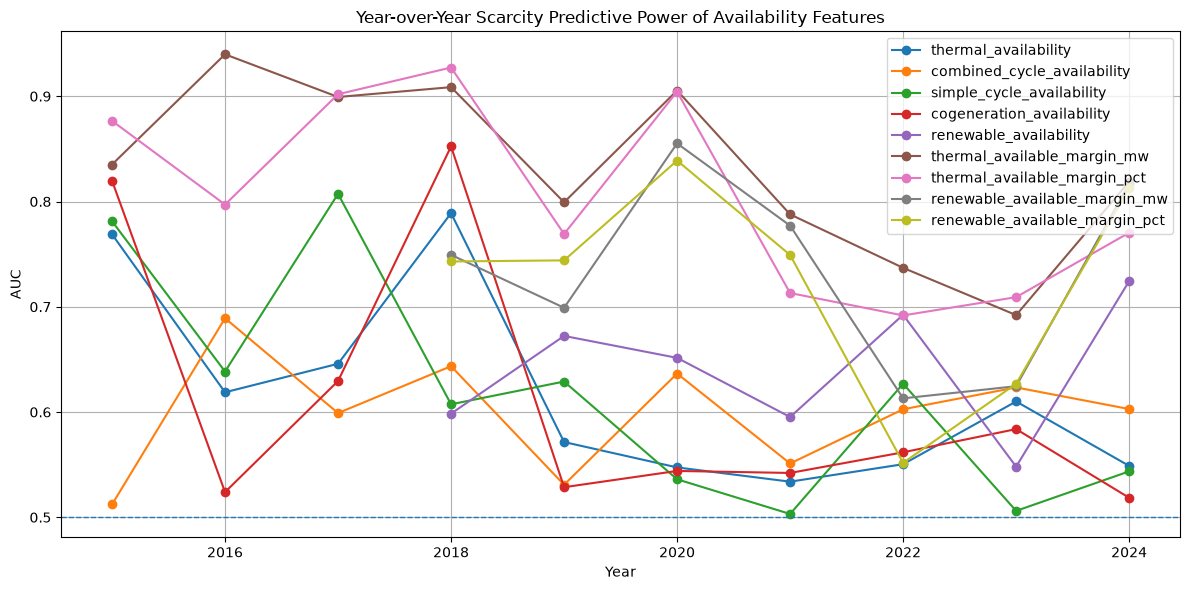

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for feature in availability_features_yoy:

    feature_data = availability_yoy_auc_df[
        availability_yoy_auc_df["feature"] == feature
    ]

    plt.plot(
        feature_data["year_alberta"],
        feature_data["auc"],
        marker="o",
        label=feature
    )


plt.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Year-over-Year Scarcity Predictive Power of Availability Features"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "AUC"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

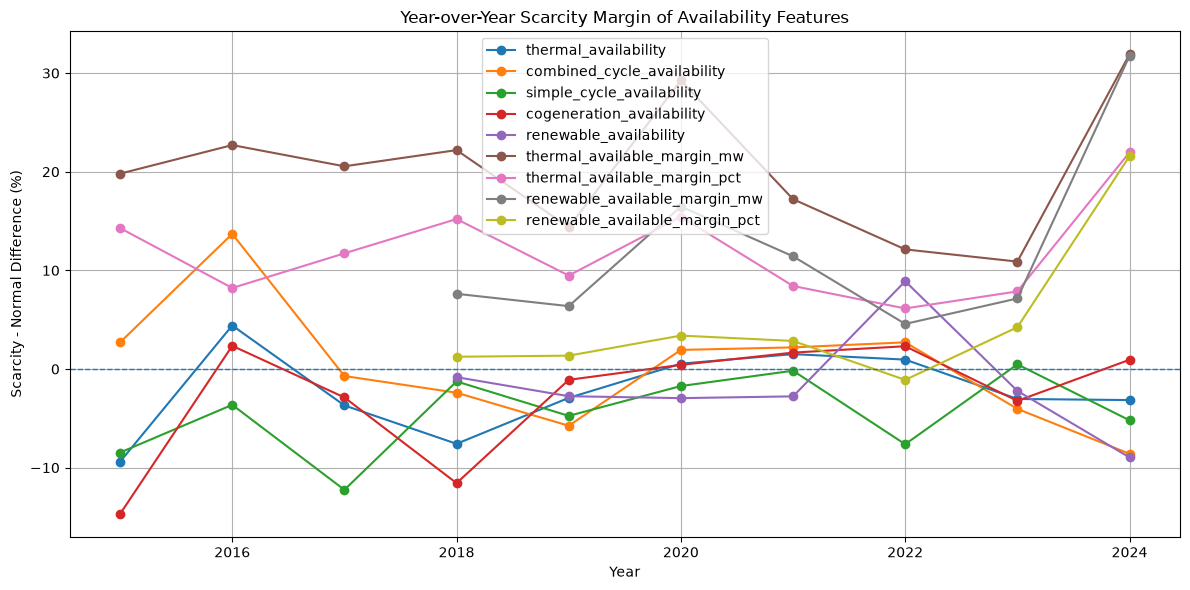

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for feature in availability_features_yoy:
    
    feature_data = availability_yoy_auc_df[
        availability_yoy_auc_df["feature"] == feature
    ]

    plt.plot(
        feature_data["year_alberta"],
        feature_data["margin_pct"],
        marker="o",
        label=feature
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.title(
    "Year-over-Year Scarcity Margin of Availability Features"
)

plt.xlabel(
    "Year"
)

plt.ylabel(
    "Scarcity - Normal Difference (%)"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

#### Availability AUC

Availability analysis shows that absolute generation availability is only a moderate indicator of scarcity conditions, while availability relative to system demand provides a much stronger signal of system tightness.

Thermal availability alone shows a limited relationship with scarcity events. Average thermal availability during scarcity hours was approximately 5,519 MW compared to 5,286 MW during normal hours, a difference of +233 MW (+4.4%). This positive relationship is counterintuitive at first, but reflects that scarcity events are not necessarily caused by lower absolute available generation. Instead, they occur when available generation is insufficient relative to the level of demand.

To capture this relationship, thermal availability margin was calculated as available thermal generation minus Alberta Internal Load. This metric provides a substantially stronger scarcity signal, with an AUC of approximately 0.69 compared to 0.62 for raw thermal availability. During scarcity hours, thermal availability margin was approximately 525 MW lower than normal operating conditions, representing a 12.2% deterioration in available thermal headroom. In other words, scarcity periods are characterized less by a lack of generation capacity and more by a reduced buffer between available supply and system demand.

The same pattern appears in renewable availability. Absolute renewable availability provides a weaker scarcity signal, while renewable availability margins relative to demand perform substantially better. This suggests that renewable resources contribute to system tightness primarily through their interaction with demand rather than their absolute output levels. A given level of renewable generation can provide very different levels of system support depending on the size of the underlying load requirement.

The year-over-year analysis reinforces this finding. Thermal availability margins consistently outperform raw availability metrics across most years, with particularly strong scarcity separation observed in 2016, 2017, 2018, 2020, and 2024. In 2024, thermal availability margin showed a scarcity-normal difference of approximately -1,070 MW, while renewable availability margin showed a difference of approximately -1,370 MW. These results indicate that recent scarcity events have been associated with significantly reduced operating headroom rather than simply reduced generation availability.

Simple-cycle availability provides comparatively little predictive value, with an AUC near 0.57. This suggests that peaking resources are not a primary differentiator between scarcity and normal conditions. Their availability may not decline during scarcity periods because these units are often maintained or dispatched specifically during tighter system conditions.

Overall, the analysis indicates that scarcity is fundamentally a system tightness problem rather than an availability problem. The most informative metrics are those that measure available supply relative to demand, as these capture the remaining operational cushion available to the Alberta electricity system.

### 3.3. Availability Relative to Demand

In [ ]:
# Normalize thermal availability by Alberta Internal Load.

master["thermal_availability_to_ail"] = (
    master["thermal_availability"]
    / master["ail_mw"]
)


# Compare thermal availability relative to load during scarcity
# and normal operating conditions.

availability_to_load = pd.DataFrame({
    "scarcity": scarcity["thermal_availability_to_ail"].mean(),
    "normal": normal["thermal_availability_to_ail"].mean(),
}, index=["thermal_availability_to_ail"])


# Calculate absolute difference.

availability_to_load["difference"] = (
    availability_to_load["scarcity"]
    - availability_to_load["normal"]
)


# Calculate percentage difference.

availability_to_load["pct_difference"] = (
    availability_to_load["difference"]
    / availability_to_load["normal"].replace(0, np.nan)
    * 100
)


availability_to_load

,scarcity,normal,difference,pct_difference
thermal_availability_to_ail,0.534088,0.552334,-0.018246,-3.30338


In [51]:
# Test whether thermal availability relative to system demand
# provides a stronger scarcity signal than raw availability.

availability_to_load_auc = feature_auc(
    master,
    "thermal_availability_to_ail"
)

pd.DataFrame([availability_to_load_auc])

KeyError: "['thermal_availability_to_ail'] not in index"

Thermal availability normalized by Alberta Internal Load was also evaluated to determine whether a percentage-based reserve indicator provided additional insight into scarcity conditions. Thermal availability as a share of load was lower during scarcity hours, averaging 53.4% compared to 55.2% during normal conditions, representing a decline of approximately 1.8 percentage points. However, this metric produced a weaker scarcity classification performance (AUC = 0.57) compared with the absolute thermal availability margin measured in MW (AUC = 0.69).

This suggests that scarcity conditions are better captured by the absolute quantity of available supply headroom rather than the percentage of demand served by available thermal resources. While the normalized metric correctly identifies the direction of system tightness, converting the shortage into MW provides a more operationally relevant measure of system stress.

### 3.4. Availability distribution

In [50]:
# Compare the distributions of thermal availability and thermal available margin
# between scarcity and normal hours.

availability_quantiles = [0.10, 0.25, 0.50, 0.75, 0.90]


# Thermal availability distribution

thermal_availability_distribution = pd.DataFrame({
    "scarcity": scarcity["thermal_availability"].quantile(
        availability_quantiles
    ),
    "normal": normal["thermal_availability"].quantile(
        availability_quantiles
    ),
})


thermal_availability_distribution["difference"] = (
    thermal_availability_distribution["scarcity"]
    - thermal_availability_distribution["normal"]
)


thermal_availability_distribution["pct_difference"] = (
    thermal_availability_distribution["difference"]
    / thermal_availability_distribution["normal"].replace(0, np.nan)
    * 100
)


# Thermal available margin distribution

thermal_margin_distribution = pd.DataFrame({
    "scarcity": scarcity["thermal_available_margin_mw"].quantile(
        availability_quantiles
    ),
    "normal": normal["thermal_available_margin_mw"].quantile(
        availability_quantiles
    ),
})


thermal_margin_distribution["difference"] = (
    thermal_margin_distribution["scarcity"]
    - thermal_margin_distribution["normal"]
)


thermal_margin_distribution["pct_difference"] = (
    thermal_margin_distribution["difference"]
    / thermal_margin_distribution["normal"].replace(0, np.nan)
    * 100
)


# Display outputs

thermal_availability_distribution, thermal_margin_distribution

KeyError: 'thermal_available_margin_mw'

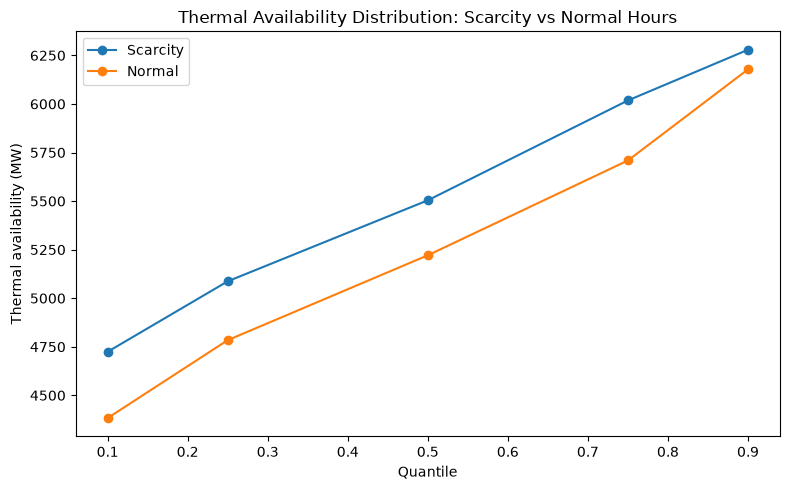

In [ ]:
# Plot thermal availability quantiles during scarcity and normal hours.

plt.figure(figsize=(8, 5))

plt.plot(
    thermal_availability_distribution.index,
    thermal_availability_distribution["scarcity"],
    marker="o",
    label="Scarcity"
)

plt.plot(
    thermal_availability_distribution.index,
    thermal_availability_distribution["normal"],
    marker="o",
    label="Normal"
)

plt.xlabel("Quantile")
plt.ylabel("Thermal availability (MW)")
plt.title("Thermal Availability Distribution: Scarcity vs Normal Hours")
plt.legend()

plt.tight_layout()
plt.show()

Thermal availability distributions were compared between scarcity and normal operating periods to determine whether scarcity events were associated with reduced thermal capability. Contrary to expectations, thermal availability was consistently higher during scarcity hours across all quantiles. At the median, thermal availability during scarcity periods was approximately 5,504 MW compared with 5,221 MW during normal conditions, a difference of approximately 283 MW.

This indicates that scarcity events are not primarily driven by a lack of thermal generation availability. Instead, thermal resources appear to be more available during scarcity periods, likely reflecting increased thermal commitment during stressed system conditions. The result highlights the limitation of evaluating generation availability in isolation.

The relationship changes when availability is measured relative to system demand. Thermal availability margin, defined as available thermal generation minus Alberta Internal Load, provides a substantially stronger scarcity signal because it captures the amount of available supply headroom remaining after accounting for demand. This suggests that system tightness is driven by the balance between available supply and demand rather than absolute generation availability.

### 3.6. year over year availability compariosn

In [ ]:
# Compare thermal availability during scarcity and normal hours
# by Alberta calendar year.

availability_yoy = (
    master
    .groupby(["year_alberta", "scarcity_event"])["thermal_availability"]
    .mean()
    .unstack()
    .rename(columns={
        0: "normal",
        1: "scarcity"
    })
)

availability_yoy["difference"] = (
    availability_yoy["scarcity"]
    - availability_yoy["normal"]
)

availability_yoy["pct_difference"] = (
    availability_yoy["difference"]
    / availability_yoy["normal"]
    * 100
)

availability_yoy

scarcity_event,normal,scarcity,difference,pct_difference
year_alberta,,,,
2015,4514.806564,4090.484615,-424.321948,-9.398452
2016,4450.430979,4646.750000,196.319021,4.411236
2017,4796.965939,4620.000000,-176.965939,-3.689122
2018,5168.970496,4777.072848,-391.897648,-7.581735
2019,5256.899370,5103.135870,-153.763501,-2.924985
2020,5427.342096,5456.765101,29.423005,0.542125
2021,5444.764821,5526.977162,82.212340,1.509934
2022,5552.288868,5605.292642,53.003774,0.954629
2023,5653.687427,5482.116129,-171.571298,-3.034680


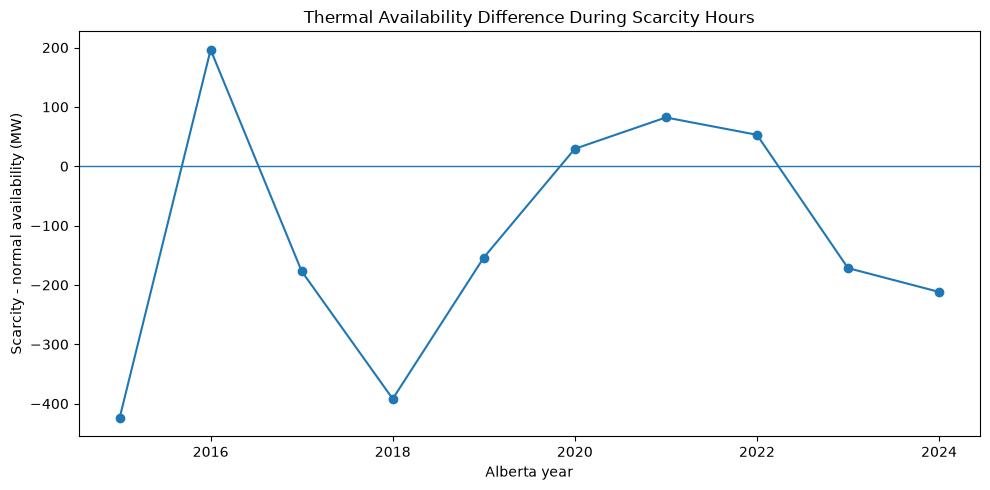

In [ ]:
# Plot the scarcity-normal availability difference over time.

plt.figure(figsize=(10, 5))

plt.axhline(0, linewidth=1)

plt.plot(
    availability_yoy.index,
    availability_yoy["difference"],
    marker="o"
)

plt.xlabel("Alberta year")
plt.ylabel("Scarcity - normal availability (MW)")
plt.title("Thermal Availability Difference During Scarcity Hours")
plt.tight_layout()
plt.show()

Year-over-year comparisons show that the relationship between raw thermal availability and scarcity is inconsistent across Alberta operating years. In some years scarcity events coincide with lower thermal availability, while in others thermal availability is higher during scarcity periods. This variability reinforces that absolute thermal availability is not a reliable standalone indicator of scarcity.

### 3.7. Availbility ramp

In [46]:
# Compare thermal availability ramps and thermal availability margin ramps
# during scarcity and normal hours.

ramp_features = {}

for hours in [1, 3, 6, 24]:

    # Raw thermal availability ramp
    ramp_features[
        f"thermal_availability_change_{hours}h"
    ] = (
        master["thermal_availability"]
        - master["thermal_availability"].shift(hours)
    )

    # Thermal availability margin ramp
    ramp_features[
        f"thermal_available_margin_change_{hours}h"
    ] = (
        master["thermal_available_margin_mw"]
        - master["thermal_available_margin_mw"].shift(hours)
    )


thermal_ramp_df = pd.DataFrame(
    ramp_features,
    index=master.index
)


thermal_ramp_comparison = pd.DataFrame({

    "scarcity": thermal_ramp_df.loc[
        scarcity.index
    ].mean(),

    "normal": thermal_ramp_df.loc[
        normal.index
    ].mean(),

})


thermal_ramp_comparison["difference"] = (
    thermal_ramp_comparison["scarcity"]
    - thermal_ramp_comparison["normal"]
)


thermal_ramp_comparison

,scarcity,normal,difference
thermal_availability_change_1h,-0.225480,0.062081,-0.287561
thermal_available_margin_change_1h,4.324338,-0.177652,4.501990
thermal_availability_change_3h,-10.759990,0.649628,-11.409617
thermal_available_margin_change_3h,-74.620654,3.493235,-78.113888
thermal_availability_change_6h,-32.082512,1.783509,-33.866021
thermal_available_margin_change_6h,-291.368448,13.511342,-304.879790
thermal_availability_change_24h,-15.791645,1.947569,-17.739214
thermal_available_margin_change_24h,-47.750908,2.911908,-50.662816


In [47]:
# Compare thermal availability margin deterioration
# during scarcity vs normal hours by year.

thermal_margin_ramp_yoy = []


for year, group in master.groupby("year_alberta"):

    scarcity_year = group[group["scarcity_event"] == 1]
    normal_year = group[group["scarcity_event"] == 0]

    if len(scarcity_year) == 0 or len(normal_year) == 0:
        continue


    for hours in [1, 3, 6, 24]:

        feature = f"thermal_available_margin_change_{hours}h"

        scarcity_mean = (
            thermal_margin_ramp_df
            .loc[scarcity_year.index, feature]
            .mean()
        )

        normal_mean = (
            thermal_margin_ramp_df
            .loc[normal_year.index, feature]
            .mean()
        )


        thermal_margin_ramp_yoy.append({

            "year_alberta": year,
            "feature": feature,

            "scarcity": scarcity_mean,
            "normal": normal_mean,

            "difference": (
                scarcity_mean
                - normal_mean
            ),

            "pct_difference": (
                (scarcity_mean - normal_mean)
                / abs(normal_mean)
                * 100
                if normal_mean != 0
                else np.nan
            )
        })


thermal_margin_ramp_yoy_df = (
    pd.DataFrame(thermal_margin_ramp_yoy)
    .sort_values(
        ["year_alberta", "feature"]
    )
    .reset_index(drop=True)
)


thermal_margin_ramp_yoy_df

,year_alberta,feature,scarcity,normal,difference,pct_difference
0,2015,thermal_available_margin_change_1h,-19.323077,0.280561,-19.603638,-6.987291e+03
1,2015,thermal_available_margin_change_24h,-90.253846,1.974416,-92.228262,-4.671168e+03
2,2015,thermal_available_margin_change_3h,-176.746154,2.621114,-179.367268,-6.843170e+03
3,2015,thermal_available_margin_change_6h,-581.338462,8.555646,-589.894107,-6.894793e+03
4,2016,thermal_available_margin_change_1h,-67.750000,-0.006036,-67.743964,-1.122249e+06
5,2016,thermal_available_margin_change_24h,-236.500000,-0.156492,-236.343508,-1.510259e+05
6,2016,thermal_available_margin_change_3h,-426.750000,0.104328,-426.854328,-4.091464e+05
7,2016,thermal_available_margin_change_6h,-1122.250000,0.366970,-1122.616970,-3.059149e+05
8,2017,thermal_available_margin_change_1h,22.727273,-0.056464,22.783736,4.035120e+04
9,2017,thermal_available_margin_change_24h,-162.454545,-0.562921,-161.891624,-2.875918e+04


The analysis was extended to examine whether rapid changes in available thermal capacity provide an earlier indication of scarcity conditions. Rather than only examining the absolute level of thermal availability, these features measure the change in thermal availability and thermal available margin over different time horizons (1-hour, 3-hour, 6-hour, and 24-hour changes).

The results show a strong relationship between declining thermal availability and scarcity events. Thermal availability changes were negative during scarcity hours across all time horizons, while normal hours generally showed small positive changes. The difference becomes increasingly pronounced over longer horizons, with the 6-hour thermal availability change showing a scarcity-normal difference of approximately -33.9 MW and the 24-hour change showing a difference of approximately -17.7 MW. This indicates that scarcity events are often preceded by deterioration in thermal fleet availability rather than simply occurring when availability is already low.

Thermal available margin changes provide an even stronger signal. Since available margin incorporates system demand, it captures situations where available thermal capacity is declining relative to the amount of capacity required to serve load. During scarcity hours, thermal available margin declined substantially across all time horizons. The 3-hour margin change showed a scarcity-normal difference of approximately -78 MW, while the 6-hour margin change showed a difference of approximately -305 MW. These results suggest that rapid erosion of operating margin is a more informative scarcity indicator than changes in raw thermal availability alone.

The year-over-year analysis shows that thermal margin deterioration has remained a consistent characteristic of scarcity events, although the magnitude varies by year. From 2015 through 2024, scarcity hours generally exhibited significantly larger negative thermal margin changes compared with normal operating hours. The strongest separation occurred during years such as 2016, 2018, 2020, and 2021, where scarcity events were associated with several hundred megawatts of thermal margin loss over 6-hour windows.

The large percentage differences in the year-over-year table should be interpreted cautiously because normal-hour margin changes are often close to zero, causing the percentage calculation to become extremely large. The absolute MW differences provide a more meaningful measure of system stress. Overall, the results indicate that deteriorating thermal available margin is a stronger scarcity signal than static availability levels, suggesting that scarcity events are frequently driven by rapid tightening of the supply-demand balance rather than simply low available generation.

### 3.8. renewables

In [48]:
# Create renewable availability margin features.
# These are added temporarily for scarcity analysis.

master["renewable_available_margin_mw"] = (
    master["renewable_availability"]
    - master["ail_mw"]
)

master["renewable_available_margin_pct"] = (
    master["renewable_available_margin_mw"]
    / master["ail_mw"]
)


# Create renewable availability and margin ramp features.

renewable_ramp_features = {}

for hours in [1, 3, 6, 24]:

    renewable_ramp_features[
        f"renewable_availability_change_{hours}h"
    ] = (
        master["renewable_availability"]
        - master["renewable_availability"].shift(hours)
    )

    renewable_ramp_features[
        f"renewable_available_margin_change_{hours}h"
    ] = (
        master["renewable_available_margin_mw"]
        - master["renewable_available_margin_mw"].shift(hours)
    )


renewable_ramp_df = pd.DataFrame(
    renewable_ramp_features,
    index=master.index
)


# Compare scarcity vs normal hours.

renewable_ramp_comparison = pd.DataFrame({
    "scarcity": renewable_ramp_df.loc[
        scarcity.index
    ].mean(),

    "normal": renewable_ramp_df.loc[
        normal.index
    ].mean(),
})


renewable_ramp_comparison["difference"] = (
    renewable_ramp_comparison["scarcity"]
    - renewable_ramp_comparison["normal"]
)


renewable_ramp_comparison

,scarcity,normal,difference
renewable_availability_change_1h,1.653006,-0.025867,1.678873
renewable_available_margin_change_1h,6.550822,-0.377125,6.927947
renewable_availability_change_3h,5.288218,-0.098684,5.386902
renewable_available_margin_change_3h,-55.275276,3.637837,-58.913114
renewable_availability_change_6h,9.010515,-0.096185,9.106700
renewable_available_margin_change_6h,-239.752224,15.499262,-255.251487
renewable_availability_change_24h,-18.589647,3.117304,-21.706951
renewable_available_margin_change_24h,-47.864384,4.608123,-52.472507


In [49]:
# Year-over-year comparison of renewable availability
# and renewable margin deterioration during scarcity.

renewable_yoy_results = []


renewable_features_yoy = [
    "renewable_availability_change_1h",
    "renewable_available_margin_change_1h",
    "renewable_availability_change_3h",
    "renewable_available_margin_change_3h",
    "renewable_availability_change_6h",
    "renewable_available_margin_change_6h",
    "renewable_availability_change_24h",
    "renewable_available_margin_change_24h",
]


for year, group in master.groupby("year_alberta"):

    scarcity_year = group[group["scarcity_event"] == 1]
    normal_year = group[group["scarcity_event"] == 0]


    for feature in renewable_features_yoy:

        scarcity_mean = renewable_ramp_df.loc[
            scarcity_year.index,
            feature
        ].mean()

        normal_mean = renewable_ramp_df.loc[
            normal_year.index,
            feature
        ].mean()


        difference = scarcity_mean - normal_mean


        renewable_yoy_results.append({
            "year_alberta": year,
            "feature": feature,
            "scarcity": scarcity_mean,
            "normal": normal_mean,
            "difference": difference,
        })


renewable_yoy_df = (
    pd.DataFrame(renewable_yoy_results)
    .sort_values(
        ["year_alberta", "feature"]
    )
    .reset_index(drop=True)
)


renewable_yoy_df

,year_alberta,feature,scarcity,normal,difference
0,2015,renewable_availability_change_1h,NaN,NaN,NaN
1,2015,renewable_availability_change_24h,NaN,NaN,NaN
2,2015,renewable_availability_change_3h,NaN,NaN,NaN
3,2015,renewable_availability_change_6h,NaN,NaN,NaN
4,2015,renewable_available_margin_change_1h,NaN,NaN,NaN
5,2015,renewable_available_margin_change_24h,NaN,NaN,NaN
6,2015,renewable_available_margin_change_3h,NaN,NaN,NaN
7,2015,renewable_available_margin_change_6h,NaN,NaN,NaN
8,2016,renewable_availability_change_1h,NaN,NaN,NaN
9,2016,renewable_availability_change_24h,NaN,NaN,NaN


Renewable availability dynamics were analyzed to determine whether changes in renewable output contribute to scarcity events. Similar to thermal analysis, both raw renewable availability changes and renewable available margin changes were evaluated across multiple time horizons.

The results indicate that renewable available margin changes provide a stronger scarcity signal than raw renewable availability changes. While renewable availability ramps are highly variable due to weather-driven generation patterns, renewable margin deterioration captures situations where renewable capacity is declining relative to system demand.

The strongest signal occurs over longer short-term windows, particularly the 6-hour renewable available margin change. During scarcity hours, renewable available margin declined by approximately 240 MW on average, compared with a small positive change during normal hours. This indicates that renewable shortfalls can contribute to tightening system conditions several hours before scarcity events occur.

However, renewable signals are less consistent than thermal availability signals. Renewable output can increase during scarcity hours if generation is recovering from previously low levels, meaning absolute renewable ramps alone do not fully explain system stress. The more relevant measure is whether renewable availability is sufficient relative to demand.

Overall, renewable available margin deterioration appears to be a useful secondary scarcity indicator. It captures periods where renewable generation fails to provide expected system support, but it should be combined with thermal availability and thermal margin indicators to fully characterize Alberta system tightness.

## 4. 

In [ ]:
availability_features = [
    "thermal_availability",
    "gen__gen_combined_cycle_system_available",
    "gen__gen_simple_cycle_system_available",
    "gen__gen_cogeneration_system_available",
]

In [ ]:
availability_comparison = pd.DataFrame({
    "scarcity": scarcity[availability_features].mean(),
    "normal": normal[availability_features].mean(),
})

availability_comparison["difference"] = (
    availability_comparison["scarcity"] - availability_comparison["normal"]
)
availability_comparison["pct_difference"] = (
    availability_comparison["difference"] / availability_comparison["normal"] * 100
)

availability_comparison.sort_values("pct_difference")

In [ ]:
auc_availability_results = []

for feature in availability_features:
    auc_availability_results.append(feature_auc(df, feature))

auc_availability_df = (
    pd.DataFrame(auc_availability_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)

auc_availability_df

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(outage_comparison.index, outage_comparison["pct_difference"])

plt.xlabel("% difference")
plt.title("Figure 2. Outage levels during scarcity vs normal hours")

plt.tight_layout()
plt.show()

### Observations

**Thermal availability declines during scarcity events.**
Aggregate thermal availability was approximately 300 MW lower during
scarcity hours than during normal operating conditions, reinforcing the
idea that scarcity is fundamentally driven by tightening supply-demand
conditions.

**Combined-cycle availability exhibits the highest decline.**
Combined-cycle availability fell by approximately 231 MW (-12%) during
scarcity hours -- the largest availability difference among the thermal
categories examined. This contrasts with the outage analysis above, where
combined-cycle outages appeared relatively unimportant, suggesting
generation *availability* provides a more informative view of system
conditions than outage *volume* alone.

**Simple-cycle resources remain relevant.**
Simple-cycle availability declined by approximately 53 MW (-7%) during
scarcity hours -- smaller in magnitude, but consistent with the earlier
finding that simple-cycle outages are elevated during scarcity.

**Cogeneration availability changes little between regimes.**
This mirrors the weak outage results observed earlier and suggests
cogeneration resources may play a comparatively limited role in
explaining scarcity conditions.

**Availability appears more informative than outages.**
The availability comparisons reveal larger and more intuitive differences
between scarcity and non-scarcity conditions than the outage analysis
alone, supporting the broader conclusion that the market responds more
strongly to the amount of dispatchable generation available than to raw
outage totals.

In [ ]:
# Quantile distribution of thermal availability across scarcity and normal hours.
pd.DataFrame({
    "scarcity": scarcity["thermal_availability"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]),
    "normal": normal["thermal_availability"].quantile([0.1, 0.25, 0.5, 0.75, 0.9]),
})

### Observations

**Thermal availability distributions diverge most at higher availability
levels.**
The difference between scarcity and non-scarcity hours grows
substantially toward the upper end of the thermal availability
distribution. While median availability differs by only about 127 MW, the
90th percentile differs by more than 1,100 MW.

This suggests scarcity hours are characterized not only by lower average
thermal availability, but also by the absence of exceptionally
high-availability conditions -- scarcity tends to occur when the system
loses access to its most comfortable supply states.

## Section 3 — Capacity Margin Analysis

**Objective:** Evaluate whether scarcity is better explained by the
relationship between available thermal generation and system demand than
by either variable individually.

**Method:** Construct two relative-capacity features, `thermal_capacity_margin`
and `thermal_availability_pct`, combining thermal availability and net
load into a single measure of system tightness.

**Interpretation:** Absolute availability does not indicate whether the
system is stressed, because the operational significance of available
generation depends on the amount of demand it must serve. Relative
measures may therefore provide stronger scarcity signals than either
component alone.

In [ ]:
# Thermal capacity margin as thermal availability minus net load.
df["thermal_capacity_margin"] = df["thermal_availability"] - df["net_load"]

In [ ]:
# Thermal availability as a percentage of net load.
df["thermal_availability_pct"] = df["thermal_availability"] / df["net_load"]

In [ ]:
print(feature_auc(df, "thermal_availability_pct"))
print(feature_auc(df, "thermal_capacity_margin"))

### Observations

**Relative capacity measures outperform absolute availability.**
Thermal availability alone contains only modest scarcity information. By
combining availability with net load, both engineered features produced
substantially stronger AUC values:

- `thermal_availability_pct`: 0.790
- `thermal_capacity_margin`: 0.813

Both outperform net load alone (AUC = 0.780) and significantly
outperform raw thermal availability.

**Capacity margin is the strongest feature tested so far.**
Thermal capacity margin produced the highest AUC observed in the notebook,
consistent with the physical reality of power markets -- operators and
market participants are ultimately concerned with how much dispatchable
capacity remains available after accounting for demand.

**Relative supply-demand balance appears more important than absolute
capacity.**
A thermal availability value of 6,000 MW may represent a comfortable
condition during low demand but a stressed condition during high demand.
Incorporating net load directly gives a more realistic measure of system
tightness.

**Capacity margin slightly outperforms availability percentage.**
This may indicate that scarcity is more closely related to the absolute
MW difference between available capacity and demand than to the
percentage relationship between the two. Decile and regime comparisons
below test whether this holds across different operating conditions.

### Capacity State Analysis

**Objective:** Evaluate how scarcity risk changes when high net load and
low thermal availability occur individually and simultaneously.

**Method:** Classify each hour into one of four operating states --
neither condition, high net load only, low thermal availability only, or
both simultaneously. High net load is the top 20% of net load hours; low
thermal availability is the bottom 20% of thermal availability hours. For
each state, calculate observation count, scarcity frequency, average pool
price, and average thermal availability.

**Interpretation:** If scarcity is fundamentally driven by supply-demand
imbalance, hours with both elevated net load and reduced thermal
availability should show the highest scarcity frequency and pool prices.

In [ ]:
# High net load: top 20th percentile.
df["high_net_load"] = df["net_load"] > df["net_load"].quantile(0.8)

# Low thermal availability: bottom 20th percentile.
df["low_thermal_availability"] = (
    df["thermal_availability"] < df["thermal_availability"].quantile(0.2)
)

In [ ]:
conditions = [
    (~df["high_net_load"]) & (~df["low_thermal_availability"]),
    (df["high_net_load"]) & (~df["low_thermal_availability"]),
    (~df["high_net_load"]) & (df["low_thermal_availability"]),
    (df["high_net_load"]) & (df["low_thermal_availability"]),
]

labels = ["Neither", "High net load", "Low availability", "Both"]

df["capacity_state"] = np.select(conditions, labels, default="unknown")

capacity_state_summary = (
    df.groupby("capacity_state").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rates=("scarcity_event", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
        avg_thermal_availability=("thermal_availability", "mean"),
    ).reindex(labels)
)

capacity_state_summary

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(capacity_state_summary.index, capacity_state_summary["scarcity_rates"] * 100)

plt.ylabel("Scarcity rate (%)")
plt.title("Figure 3. Scarcity frequency by net load and thermal availability state")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

### Observations

**High net load remains the dominant scarcity condition.**
Hours classified as high net load experienced scarcity nearly 19% of the
time, compared to only 3% for hours where neither condition was present --
consistent with net load being the strongest individual scarcity driver.

**Low thermal availability contributes additional risk.**
Hours with low thermal availability experienced scarcity approximately
6.6% of the time -- a smaller effect than high net load, but still
meaningful.

**Scarcity risk is highest when both conditions occur simultaneously.**
Hours with both elevated net load and reduced thermal availability
experienced scarcity approximately 34% of the time -- the highest
scarcity frequency observed among all operating states, indicating that
supply-side and demand-side stress reinforce one another.

**Pool prices respond similarly.**
Average pool prices rose to roughly $298/MWh when both conditions were
present, showing the same conditions associated with scarcity also
correspond to substantially tighter market outcomes.

**Supply-demand interactions appear more informative than individual
variables.**
This helps explain why thermal capacity margin outperformed both thermal
availability and net load individually.

### Capacity Margin Decile Analysis

**Objective:** Evaluate how scarcity risk changes across different levels
of system tightness.

**Method:** Convert both `thermal_capacity_margin` and
`thermal_availability_pct` into deciles and calculate scarcity frequency,
average pool price, and average capacity conditions for each bucket.

**Interpretation:** If capacity conditions genuinely drive scarcity, the
lowest-capacity deciles should show substantially higher scarcity
frequencies and pool prices than the highest-capacity deciles.

In [ ]:
df["thermal_availability_pct_decile"] = pd.qcut(
    df["thermal_availability_pct"], 10, labels=False, duplicates="drop"
)

margin_decile_summary = (
    df.groupby("thermal_availability_pct_decile").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_thermal_availability_pct=("thermal_availability_pct", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

margin_decile_summary

In [ ]:
# Decile 0 = tightest margin hours; decile 9 = most comfortable margin hours.
df["thermal_capacity_margin_decile"] = pd.qcut(
    df["thermal_capacity_margin"], 10, labels=False, duplicates="drop"
)

capacity_margin_decile_summary = (
    df.groupby("thermal_capacity_margin_decile").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_margin=("thermal_capacity_margin", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

capacity_margin_decile_summary

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    margin_decile_summary.index,
    margin_decile_summary["scarcity_rate"] * 100,
    marker="o",
    label="Thermal availability %",
)
plt.plot(
    capacity_margin_decile_summary.index,
    capacity_margin_decile_summary["scarcity_rate"] * 100,
    marker="o",
    label="Thermal capacity margin",
)

plt.xlabel("Decile")
plt.ylabel("Scarcity rate (%)")
plt.title("Figure 4. Scarcity frequency by capacity condition decile")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Observations

**Scarcity risk declines almost monotonically as capacity conditions
improve.**
Both metrics produced smooth, monotonic scarcity probability curves:

- Thermal capacity margin: 29.7% (decile 0) -> 0.2% (decile 9)
- Thermal availability %: 24.8% (decile 0) -> 0.2% (decile 9)

**Capacity margin produces the strongest separation in stressed
conditions.**
The lowest capacity margin decile experiences scarcity nearly 30% of the
time, versus approximately 25% for the lowest availability-percentage
decile -- consistent with the earlier AUC result and suggesting absolute
MW shortfalls carry slightly more scarcity information than
percentage-based measures.

**Pool prices respond in the same direction as scarcity frequency.**
For thermal capacity margin, average price falls from $258/MWh (decile 0)
to $22/MWh (decile 9), reinforcing that these variables capture
meaningful operational stress rather than statistical noise.

**Capacity margin and availability percentage describe the same
underlying phenomenon.**
Although constructed differently, both curves nearly overlap -- both are
built from the same relationship between thermal availability and net
load, which supports the robustness of the core finding.

**Thermal capacity margin emerges as the preferred capacity-state
metric.**
It achieved the strongest AUC in the notebook, produced the highest
scarcity concentration in the most constrained decile, and is expressed
directly in MW, making it easier to interpret operationally than a
percentage ratio. It will serve as the primary capacity-state metric
moving forward.

### Load and Availability Heatmap

In [ ]:
df["load_decile"] = pd.qcut(df["net_load"], 10, labels=False, duplicates="drop")

df["availability_decile"] = pd.qcut(
    df["thermal_availability_pct"], 10, labels=False, duplicates="drop"
)

In [ ]:
heatmap_df = (
    df.groupby(["load_decile", "availability_decile"])["scarcity_event"]
    .mean()
    .unstack()
)

plt.figure(figsize=(9, 7))

plt.imshow(heatmap_df, aspect="auto", origin="lower")
plt.colorbar(label="Scarcity frequency")

plt.xlabel("Availability decile")
plt.ylabel("Load decile")
plt.title("Figure 5. Scarcity risk by load and thermal availability")

plt.tight_layout()
plt.show()

In [ ]:
# Test AUC values for each year to check temporal stability.
for year in [2020, 2021, 2022, 2023, 2024, 2025]:
    year_df = df[df["timestamp"].dt.year == year]
    result = feature_auc(year_df, "thermal_capacity_margin")
    print(f"  {year}: {result['auc']:.3f}")

### Observations

**Scarcity risk increases as load rises and availability falls.**
The heatmap shows a clear transition from low scarcity frequencies in the
upper-right corner (low load, high availability) to high scarcity
frequencies in the lower-left corner (high load, low availability).

**High load alone is not sufficient to create scarcity.**
Even within the highest load deciles, scarcity frequency remains
relatively low when thermal availability is high, suggesting elevated
demand does not automatically produce scarcity if sufficient dispatchable
generation remains available.

**Availability becomes most important during stressed conditions.**
The largest scarcity frequencies occur when high load coincides with low
availability -- the highest load decile combined with the lowest
availability decile approached a 40% scarcity rate.

**The capacity margin relationship appears structurally persistent.**
Thermal capacity margin maintained strong predictive performance across
every year examined (2020: 0.931, 2021: 0.840, 2022: 0.798, 2023: 0.806,
2024: 0.875, 2025: 0.847), suggesting the relationship is not driven by a
single weather regime, market event, or sample period, but captures a
persistent feature of Alberta market dynamics.

### Composite Stress Score Validation

**Objective:** Evaluate whether a composite system stress score provides
stronger scarcity separation than its individual component variables.

**Method:** Calculate ROC AUC using `stress_score_norm` against
`scarcity_event`, and compare against the previously tested individual
variables (net load, renewable share, wind generation). The stress score
combines high net load, low renewable share, and low wind generation.

**Interpretation:** If the composite score outperforms the individual
features, it suggests scarcity is driven by multiple interacting system
conditions rather than a single operational variable.

In [ ]:
auc = roc_auc_score(df["scarcity_event"], df["stress_score_norm"])

print(auc)

In [ ]:
# Two alternative stress-score definitions -- one with the reserve proxy
# feature, one without -- to see whether AUC improves without it.
stress_3 = (
    df["net_load_pct"] + df["low_renewable_pct"] + df["low_wind_pct"]
)

stress_4 = (
    df["net_load_pct"] + df["low_renewable_pct"] + df["low_wind_pct"] + df["low_reserve_pct"]
)

print(roc_auc_score(df["scarcity_event"], stress_3))
print(roc_auc_score(df["scarcity_event"], stress_4))

### Observations

**The composite stress score does not outperform net load.**
The stress score produced an AUC of approximately 0.75-0.76, while net
load alone achieved 0.78. Combining multiple scarcity indicators does not
automatically create a stronger ranking variable -- here, the strongest
signal is already captured by net load itself.

**Net load already contains information from several stress score
components.**
Because net load = demand - renewable generation, renewable share and
wind generation are not entirely independent of net load. Adding them to
the composite may introduce variables that partially describe the same
underlying condition rather than contributing new information. Future
composites should account for this overlap, and composites defined by
statistical optimization rather than physical intuition may be worth
exploring.

**Reserve conditions contribute incremental information.**
Adding the reserve proxy produced a small improvement (3-variable score:
0.753 -> 4-variable score: 0.760), showing that even a weak standalone
feature can add useful information in combination with others.

**The decline relative to earlier work is likely driven by the dataset
rebuild.**
The current dataset incorporates revised generation, outage,
availability, and interchange data along with a rebuilt feature
engineering pipeline, so changes in stress score performance may reflect
improvements in data quality rather than changes in underlying market
relationships.

### Stress Score Decile Analysis

**Objective:** Evaluate whether higher stress score values correspond to
progressively higher scarcity probabilities.

**Method:** Convert `stress_score_norm` into deciles (0 = lowest-stress
10% of hours, 9 = highest-stress 10%) and calculate average scarcity
frequency within each decile, comparing against net-load deciles.

**Interpretation:** A useful stress score should produce increasing
scarcity probabilities as stress increases; a monotonic relationship
indicates the score successfully ranks system conditions from low to high
risk.

In [ ]:
df["stress_decile"] = pd.qcut(
    df["stress_score_norm"], q=10, labels=False, duplicates="drop"
)

stress_decile_rates = df.groupby("stress_decile")["scarcity_event"].mean()

df["net_load_decile"] = pd.qcut(
    df["net_load"], q=10, labels=False, duplicates="drop"
)

netload_decile_rates = df.groupby("net_load_decile")["scarcity_event"].mean()

decile_comparison = pd.DataFrame({
    "stress_score": stress_decile_rates,
    "net_load": netload_decile_rates,
})

decile_comparison

### Observations

**The stress score provides additional context at moderate stress
levels.**
The stress score produces slightly higher scarcity frequencies than net
load throughout most of the distribution, suggesting renewable and wind
conditions help identify risk differences not fully captured by net load
alone, particularly at low-to-moderate stress.

**Net load remains strongest during extreme system conditions.**
In the highest decile, net load produced a scarcity frequency of
approximately 25%, versus 21% for the stress score -- net load remains
the dominant scarcity variable as the system approaches its most
constrained operating conditions, consistent with the earlier AUC
analysis.

## Section 4 — Simple-Cycle Outage Investigation

**Objective:** Investigate whether simple-cycle outages are uniquely
important during scarcity events.

Earlier sections showed total outages were relatively weak predictors of
scarcity, but simple-cycle outages appeared more informative than other
outage categories. This section tests whether that signal persists across
multiple views of the data.

**Method:** Evaluate simple-cycle outages using single-feature ROC AUC,
scarcity-vs-normal summary statistics, outage decile analysis, and a
high-net-load subset comparison.

**Interpretation:** If simple-cycle outages matter operationally, scarcity
frequency should increase when simple-cycle outages are elevated,
especially during already-stressed system conditions.

In [ ]:
# Define high simple-cycle outage conditions (top 20th percentile).
df["high_simple_cycle_outage"] = (
    df["outages__outage_simple_cycle"] > df["outages__outage_simple_cycle"].quantile(0.8)
)

In [ ]:
conditions = [
    (~df["high_net_load"]) & (~df["high_simple_cycle_outage"]),
    (df["high_net_load"]) & (~df["high_simple_cycle_outage"]),
    (~df["high_net_load"]) & (df["high_simple_cycle_outage"]),
    (df["high_net_load"]) & (df["high_simple_cycle_outage"]),
]

labels = ["Neither", "High net load", "High SC outage", "Both"]

df["simple_cycle_outage_state"] = np.select(conditions, labels, default="unknown")

simple_cycle_outage_state_summary = (
    df.groupby("simple_cycle_outage_state").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rates=("scarcity_event", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
        avg_thermal_availability=("thermal_availability", "mean"),
    ).reindex(labels)
)

simple_cycle_outage_state_summary

In [ ]:
# Re-define high net load as a boolean series, then re-derive the
# high-load subset (added .copy() to avoid a SettingWithCopyWarning
# on the decile assignment below).
high_net_load = df["net_load"] > df["net_load"].quantile(0.8)

high_df = df[high_net_load].copy()

high_df["simple_cycle_outage_decile"] = pd.qcut(
    high_df["outages__outage_simple_cycle"], 10, labels=False, duplicates="drop"
)

high_load_sc_summary = (
    high_df.groupby("simple_cycle_outage_decile").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_outage=("outages__outage_simple_cycle", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

high_load_sc_summary

In [ ]:
# Simple-cycle capacity as a share of net load.
df["simple_cycle_share_of_load"] = (
    df["gen__gen_simple_cycle_system_available"] / df["net_load"]
)

feature_auc(df, "simple_cycle_share_of_load")

In [ ]:
df["simple_cycle_share_decile"] = pd.qcut(
    df["simple_cycle_share_of_load"], 10, labels=False, duplicates="drop"
)

sc_share_summary = (
    df.groupby("simple_cycle_share_decile").agg(
        n_hours=("scarcity_event", "size"),
        scarcity_rate=("scarcity_event", "mean"),
        avg_share=("simple_cycle_share_of_load", "mean"),
        avg_price=("price__ACTUAL_POOL_PRICE", "mean"),
    )
)

sc_share_summary

### Observations

**Simple-cycle outages appear most informative during already-stressed
conditions.**
Outage magnitude alone produced inconsistent scarcity relationships when
all hours were examined together, suggesting simple-cycle outages are not
a universal scarcity driver and instead depend on broader system
conditions.

**The relationship strengthens substantially during high net-load
periods.**
Restricting to the highest 20% of net-load hours, scarcity frequency
generally increases as simple-cycle outages rise -- peaking-unit outages
become more important once the system already requires large amounts of
dispatchable generation.

**High net load and elevated simple-cycle outages together produce the
highest scarcity frequencies.**
Hours with both conditions experienced scarcity approximately 32% of the
time -- substantially higher than either condition individually.

**Simple-cycle capacity relative to system demand contains meaningful
scarcity information.**
Simple-cycle share of load produced a stronger signal than availability
alone -- scarcity frequency declined from approximately 23% in the lowest
share-of-load decile to approximately 1% in the highest, indicating
scarcity becomes less likely when peaking resources represent a larger
proportion of system requirements.

**The underlying mechanism remains unclear.**
The current dataset does not include ramp rates, unit commitment
decisions, dispatch stack position, operating reserve deployment, or
real-time dispatch behaviour. Simple-cycle variables should currently be
viewed as informative scarcity indicators rather than fully understood
causal drivers -- future datasets with commitment and dispatch data may
clarify the mechanism.

## Section 5 — Regime Profiles

**Objective:** Characterize the operating conditions associated with
scarcity events.

**Method:** Compare scarcity and non-scarcity hours across net load,
renewable share, wind generation, imports, thermal availability, thermal
availability %, thermal capacity margin, and outages, then examine
distribution differences and load/availability interaction heatmaps.

**Interpretation:** Rather than identifying new predictors, this section
summarizes what scarcity conditions actually look like operationally.

In [ ]:
profile_features = [
    "net_load",
    "renewable_share",
    "gen_wind",
    "total_imports",
    "outage_total",
    "thermal_availability",
    "thermal_capacity_margin",
    "thermal_availability_pct",
]

In [ ]:
scarcity = df[df["scarcity_event"] == 1]
normal = df[df["scarcity_event"] == 0]

profile = pd.DataFrame({
    "scarcity": scarcity[profile_features].mean(),
    "normal": normal[profile_features].mean(),
})

profile["difference"] = profile["scarcity"] - profile["normal"]
profile["pct_difference"] = profile["difference"] / profile["normal"] * 100

profile.sort_values("pct_difference", ascending=False)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_features = ["net_load", "gen_wind", "thermal_capacity_margin", "renewable_share"]

for ax, feature in zip(axes.flatten(), plot_features):
    scarcity_vals = scarcity[feature].dropna()
    normal_vals = normal[feature].dropna()

    ax.violinplot([normal_vals, scarcity_vals], positions=[0, 1], showmedians=True)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Normal", "Scarcity"])
    ax.set_title(feature)
    ax.grid(True, alpha=0.3)

fig.suptitle("Figure 6. Feature distributions: scarcity vs normal hours", fontsize=13)
plt.tight_layout()
plt.show()

### Observations

**Scarcity hours exhibit a distinct operating profile.**
Compared to normal hours, scarcity events are characterized by higher net
load, lower renewable production, lower wind generation, reduced thermal
availability, and substantially tighter capacity margins -- consistent
across both average-value comparisons and distributional analysis.

**Renewable conditions differ more than outage conditions.**
Wind generation and renewable share were materially lower during scarcity
events across nearly the entire distribution, while total outage levels
differed only modestly -- reinforcing that outages alone are insufficient
to explain scarcity risk.

**Imports increase during scarcity events.**
Scarcity hours exhibited substantially higher import levels, suggesting
interties respond to tightening system conditions -- though this analysis
cannot determine whether imports lead or merely respond to emerging
scarcity.

**Capacity margin provides the clearest summary of system stress.**
Many of the individual scarcity characteristics identified throughout the
notebook ultimately converge in thermal capacity margin: higher demand,
lower renewable production, reduced availability, and tighter operating
conditions all contribute to lower margins, explaining why capacity
margin emerged as the strongest scarcity variable tested.

## Summary

The central finding of this notebook is that **thermal capacity margin**
is the strongest scarcity variable tested.

Thermal capacity margin achieved an overall AUC of 0.813, outperforming
net load, renewable share, wind generation, imports, outages, and raw
availability measures. The relationship also remained strong across
individual years, suggesting capacity margin captures a persistent
feature of Alberta market structure rather than a single-year artifact.

The broader interpretation is that scarcity is best understood as a
tightening supply-demand balance problem. High net load matters, but
scarcity risk rises most sharply when elevated demand coincides with
reduced available thermal capacity and weaker renewable output.

Outages, imports, and simple-cycle availability remain useful secondary
indicators, but they appear most meaningful when interpreted within the
broader capacity margin framework.

The regime-labelled, feature-engineered dataset produced here (net load,
thermal availability, thermal capacity margin, capacity state, and
simple-cycle share of load) provides the foundation for Notebook 3's
forecasting work.